# Extracción de características y clustering exploratorio de las trayectorias estatales de dengue

## 1. Carga y validación de las series semanales

En los notebooks anteriores se construyeron las series semanales de casos e incidencia de dengue para las 32 entidades federativas, así como las matrices de covariables meteorológicas obtenidas de NASA POWER.

En este notebook se utilizará el periodo 2020--2025 para construir una representación compacta e interpretable de las trayectorias estatales. En particular, se calcularán características relacionadas con:

- magnitud de la incidencia;
- variabilidad;
- persistencia;
- estacionalidad;
- intensidad de los brotes;
- condiciones climáticas generales.

Como primer paso, se cargarán y validarán las siguientes matrices semanales:

- casos de dengue;
- incidencia por cada 100,000 habitantes;
- temperatura media;
- humedad relativa;
- precipitación.

Se verificará que todas las matrices tengan:

1. fechas correctamente ordenadas;
2. los mismos 32 estados;
3. una cobertura temporal compatible;
4. ausencia de valores faltantes;
5. nombres estatales consistentes.

En esta etapa todavía no se aplicará ningún método de clustering. El objetivo es comprobar que los datos de entrada estén correctamente alineados antes de construir las características estatales.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    cophenet
)

from scipy.spatial.distance import pdist

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics import silhouette_samples


import unicodedata
import geopandas as gpd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [2]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


BASE_DIR = Path("datos_dengue_historicos")

SERIES_DIR = BASE_DIR / "series_temporales"

CLIMATE_DIR = (
    BASE_DIR
    / "nasa_power"
    / "matrices_semanales"
)


# Archivos que se utilizarán 

ARCHIVOS = {
    "CASOS": (
        SERIES_DIR
        / "casos_semanales_dengue_por_estado_2020_2026.csv"
    ),
    "INCIDENCIA": (
        SERIES_DIR
        / "incidencia_semanal_dengue_por_estado_2020_2026.csv"
    ),
    "T2M": (
        CLIMATE_DIR
        / "t2m_semanal_por_estado_2020_2026.csv"
    ),
    "RH2M": (
        CLIMATE_DIR
        / "rh2m_semanal_por_estado_2020_2026.csv"
    ),
    "PRECIP": (
        CLIMATE_DIR
        / "prectotcorr_semanal_por_estado_2020_2026.csv"
    ),
}


# Verificar que todos los archivos existan

archivos_faltantes = [
    str(ruta)
    for ruta in ARCHIVOS.values()
    if not ruta.exists()
]

if archivos_faltantes:
    raise FileNotFoundError(
        "No se encontraron los siguientes archivos:\n"
        + "\n".join(archivos_faltantes)
    )


def cargar_matriz_semanal(ruta):
    """
    Carga una matriz semanal con:
        filas    = fechas,
        columnas = estados.
    """

    matriz = pd.read_csv(
        ruta,
        parse_dates=["FECHA"],
        index_col="FECHA"
    )

    matriz.index = pd.DatetimeIndex(matriz.index)
    matriz.index.name = "FECHA"

    matriz.columns = (
        matriz.columns
        .astype(str)
        .str.strip()
    )

    matriz = matriz.sort_index()

    return matriz


# Cargar matrices

matrices = {
    nombre: cargar_matriz_semanal(ruta)
    for nombre, ruta in ARCHIVOS.items()
}

casos = matrices["CASOS"]
incidencia = matrices["INCIDENCIA"]
t2m = matrices["T2M"]
rh2m = matrices["RH2M"]
precip = matrices["PRECIP"]


# Resumen de las matrices cargadas

resumen = []

for nombre, matriz in matrices.items():

    resumen.append(
        {
            "MATRIZ": nombre,
            "FILAS": matriz.shape[0],
            "ESTADOS": matriz.shape[1],
            "FECHA_INICIAL": matriz.index.min(),
            "FECHA_FINAL": matriz.index.max(),
            "FALTANTES": int(
                matriz.isna().sum().sum()
            ),
            "DUPLICADOS_FECHA": int(
                matriz.index.duplicated().sum()
            )
        }
    )

resumen = pd.DataFrame(resumen)

print("Resumen de las matrices semanales:")
display(resumen)


# Verificar concordancia de fechas y estados

indice_referencia = incidencia.index
estados_referencia = set(incidencia.columns)

mismas_fechas = {
    nombre: matriz.index.equals(indice_referencia)
    for nombre, matriz in matrices.items()
}

mismos_estados = {
    nombre: set(matriz.columns) == estados_referencia
    for nombre, matriz in matrices.items()
}

validacion = pd.DataFrame(
    {
        "MISMAS_FECHAS_QUE_INCIDENCIA": mismas_fechas,
        "MISMOS_ESTADOS_QUE_INCIDENCIA": mismos_estados
    }
)

print("\nValidación de alineación:")
display(validacion)




estados_ordenados = sorted(incidencia.columns)

print("\nNúmero de estados:")
print(len(estados_ordenados))

print("\nEstados disponibles:")
print(estados_ordenados)

Resumen de las matrices semanales:


,MATRIZ,FILAS,ESTADOS,FECHA_INICIAL,FECHA_FINAL,FALTANTES,DUPLICADOS_FECHA
0,CASOS,334,32,2020-01-05,2026-05-24,0,0
1,INCIDENCIA,334,32,2020-01-05,2026-05-24,0,0
2,T2M,334,32,2020-01-05,2026-05-24,0,0
3,RH2M,334,32,2020-01-05,2026-05-24,0,0
4,PRECIP,334,32,2020-01-05,2026-05-24,0,0



Validación de alineación:


,MISMAS_FECHAS_QUE_INCIDENCIA,MISMOS_ESTADOS_QUE_INCIDENCIA
CASOS,True,True
INCIDENCIA,True,True
T2M,True,True
RH2M,True,True
PRECIP,True,True



Número de estados:
32

Estados disponibles:
['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA', 'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO', 'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON', 'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI', 'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ', 'YUCATAN', 'ZACATECAS']


## 2. Definición del periodo de análisis

Aunque las matrices semanales cubren desde enero de 2020 hasta mayo de 2026, no todas las observaciones corresponden a periodos completos.

La primera semana, etiquetada como 5 de enero de 2020, contiene únicamente los días comprendidos entre el 1 y el 5 de enero. Asimismo, la información epidemiológica de 2026 sólo se encuentra disponible hasta el 20 de mayo, por lo que no representa un año completo y la última semana contiene menos días de observación epidemiológica que de observación climática.

Para evitar que estas diferencias afecten el cálculo de características como la incidencia media, la proporción de semanas sin casos, la estacionalidad o la persistencia de los brotes, se utilizará inicialmente el periodo formado por semanas completas entre:

$$
\text{12 de enero de 2020}
\quad\text{y}\quad
\text{28 de diciembre de 2025}.
$$

El año 2026 no se eliminará de las bases originales. Se reservará para etapas posteriores, como la actualización temporal de los clústeres o la evaluación de pronósticos.

En esta sección se recortarán simultáneamente todas las matrices y se verificará nuevamente su alineación.

In [3]:
# Selección de semanas completas del periodo 2020--2025

FECHA_INICIAL_ANALISIS = pd.Timestamp("2020-01-12")
FECHA_FINAL_ANALISIS = pd.Timestamp("2025-12-28")


def seleccionar_periodo(matriz, fecha_inicial, fecha_final):
    """
    Selecciona un periodo temporal cerrado de una matriz semanal.
    """

    resultado = matriz.loc[
        (matriz.index >= fecha_inicial)
        & (matriz.index <= fecha_final)
    ].copy()

    return resultado


# Recortar todas las matrices con el mismo intervalo temporal

matrices_2020_2025 = {
    nombre: seleccionar_periodo(
        matriz,
        FECHA_INICIAL_ANALISIS,
        FECHA_FINAL_ANALISIS
    )
    for nombre, matriz in matrices.items()
}


# Crear objetos individuales para facilitar su uso posterior

casos_2020_2025 = matrices_2020_2025["CASOS"]
incidencia_2020_2025 = matrices_2020_2025["INCIDENCIA"]
t2m_2020_2025 = matrices_2020_2025["T2M"]
rh2m_2020_2025 = matrices_2020_2025["RH2M"]
precip_2020_2025 = matrices_2020_2025["PRECIP"]


# Resumen del periodo seleccionado

resumen_periodo = []

for nombre, matriz in matrices_2020_2025.items():

    resumen_periodo.append(
        {
            "MATRIZ": nombre,
            "FILAS": matriz.shape[0],
            "ESTADOS": matriz.shape[1],
            "FECHA_INICIAL": matriz.index.min(),
            "FECHA_FINAL": matriz.index.max(),
            "FALTANTES": int(
                matriz.isna().sum().sum()
            )
        }
    )

resumen_periodo = pd.DataFrame(resumen_periodo)

print("Matrices correspondientes a semanas completas de 2020--2025:")
display(resumen_periodo)


# Verificar nuevamente la alineación

indice_referencia_2020_2025 = incidencia_2020_2025.index
columnas_referencia_2020_2025 = incidencia_2020_2025.columns

for nombre, matriz in matrices_2020_2025.items():

    assert matriz.index.equals(
        indice_referencia_2020_2025
    ), f"Las fechas de {nombre} no coinciden."

    assert matriz.columns.equals(
        columnas_referencia_2020_2025
    ), f"El orden de los estados de {nombre} no coincide."

    assert matriz.isna().sum().sum() == 0, (
        f"La matriz {nombre} contiene valores faltantes."
    )


# Verificar que las fechas mantengan frecuencia semanal

diferencias_dias = (
    incidencia_2020_2025.index
    .to_series()
    .diff()
    .dropna()
    .dt.days
)

print("\nDistribución de la separación entre fechas consecutivas:")
display(
    diferencias_dias
    .value_counts()
    .sort_index()
    .rename_axis("DÍAS")
    .reset_index(name="FRECUENCIA")
)


# Comparar los casos incluidos y excluidos del análisis

casos_totales_base = casos.to_numpy().sum()
casos_periodo = casos_2020_2025.to_numpy().sum()
casos_excluidos = casos_totales_base - casos_periodo

comparacion_casos = pd.DataFrame(
    {
        "CONCEPTO": [
            "Casos en la base semanal completa",
            "Casos incluidos en el periodo 2020--2025",
            "Casos excluidos del análisis inicial"
        ],
        "CASOS": [
            int(casos_totales_base),
            int(casos_periodo),
            int(casos_excluidos)
        ]
    }
)

comparacion_casos["PORCENTAJE_BASE"] = (
    100
    * comparacion_casos["CASOS"]
    / casos_totales_base
)

print("\nCobertura epidemiológica del periodo seleccionado:")
display(comparacion_casos)


print("\nValidación terminada correctamente.")
print(
    f"Periodo de análisis: "
    f"{FECHA_INICIAL_ANALISIS.date()} a "
    f"{FECHA_FINAL_ANALISIS.date()}"
)
print(
    f"Número de semanas completas: "
    f"{len(incidencia_2020_2025)}"
)
print(
    f"Número de estados: "
    f"{incidencia_2020_2025.shape[1]}"
)

Matrices correspondientes a semanas completas de 2020--2025:


,MATRIZ,FILAS,ESTADOS,FECHA_INICIAL,FECHA_FINAL,FALTANTES
0,CASOS,312,32,2020-01-12,2025-12-28,0
1,INCIDENCIA,312,32,2020-01-12,2025-12-28,0
2,T2M,312,32,2020-01-12,2025-12-28,0
3,RH2M,312,32,2020-01-12,2025-12-28,0
4,PRECIP,312,32,2020-01-12,2025-12-28,0



Distribución de la separación entre fechas consecutivas:


,DÍAS,FRECUENCIA
0,7,311



Cobertura epidemiológica del periodo seleccionado:


,CONCEPTO,CASOS,PORCENTAJE_BASE
0,Casos en la base semanal completa,242999,100.0000
1,Casos incluidos en el periodo 2020--2025,240688,99.0490
2,Casos excluidos del análisis inicial,2311,0.9510



Validación terminada correctamente.
Periodo de análisis: 2020-01-12 a 2025-12-28
Número de semanas completas: 312
Número de estados: 32


## 3. Características de magnitud, variabilidad y frecuencia de semanas sin casos

Para comparar las trayectorias epidemiológicas de las 32 entidades federativas, las series semanales se resumirán mediante características interpretables.

En esta primera etapa se considerarán tres componentes:

### Magnitud de la incidencia

Para cada estado se calcularán:

- incidencia semanal media;
- incidencia semanal mediana;
- percentil 90;
- incidencia semanal máxima.

Estas medidas permiten distinguir estados con niveles persistentemente altos de incidencia de aquellos que presentan brotes intensos pero poco frecuentes.

### Variabilidad

Se calcularán:

- desviación estándar;
- rango intercuartílico;
- coeficiente de variación.

El coeficiente de variación se define como

$$
CV_i=\frac{s_i}{\overline{I}_i},
$$

donde $\overline{I}_i$ y $s_i$ representan la media y la desviación estándar de la incidencia semanal del estado $i$, respectivamente.

### Frecuencia de actividad epidemiológica

También se obtendrán:

- número de semanas con al menos un caso;
- proporción de semanas sin casos;
- número total de casos en el periodo.

La proporción de semanas sin casos se define como

$$
p_{0,i}=
\frac{
\#\{t:I_{i,t}=0\}
}{
T
},
$$

donde $T=312$ es el número de semanas analizadas.

Los casos acumulados se utilizarán solamente como referencia descriptiva, ya que dependen del tamaño poblacional. Para el clustering se dará prioridad a las características calculadas a partir de la incidencia.

In [4]:
# Características de magnitud, variabilidad y semanas sin casos

N_SEMANAS = len(incidencia_2020_2025)


def coeficiente_variacion(serie):
    """
    Calcula el coeficiente de variación de una serie.
    Devuelve NaN si la media es igual a cero.
    """

    media = serie.mean()

    if np.isclose(media, 0):
        return np.nan

    return serie.std(ddof=1) / media


# Características basadas en la incidencia semanal

features_magnitud = pd.DataFrame(
    index=incidencia_2020_2025.columns
)

features_magnitud.index.name = "ESTADO"

features_magnitud["INC_MEDIA"] = (
    incidencia_2020_2025.mean(axis=0)
)

features_magnitud["INC_MEDIANA"] = (
    incidencia_2020_2025.median(axis=0)
)

features_magnitud["INC_P90"] = (
    incidencia_2020_2025.quantile(0.90, axis=0)
)

features_magnitud["INC_MAX"] = (
    incidencia_2020_2025.max(axis=0)
)

features_magnitud["INC_DESV_EST"] = (
    incidencia_2020_2025.std(axis=0, ddof=1)
)

features_magnitud["INC_RIC"] = (
    incidencia_2020_2025.quantile(0.75, axis=0)
    - incidencia_2020_2025.quantile(0.25, axis=0)
)

features_magnitud["INC_CV"] = (
    incidencia_2020_2025.apply(
        coeficiente_variacion,
        axis=0
    )
)

features_magnitud["SEMANAS_POSITIVAS"] = (
    incidencia_2020_2025.gt(0).sum(axis=0)
)

features_magnitud["PROP_SEMANAS_CERO"] = (
    incidencia_2020_2025.eq(0).mean(axis=0)
)



# Información descriptiva basada en el número de casos
features_magnitud["CASOS_TOTALES"] = (
    casos_2020_2025.sum(axis=0)
)

features_magnitud["CASOS_PROM_SEMANA"] = (
    casos_2020_2025.mean(axis=0)
)


# Validaciones

assert features_magnitud.shape[0] == 32

assert features_magnitud[
    "PROP_SEMANAS_CERO"
].between(0, 1).all()

semanas_cero = (
    incidencia_2020_2025.eq(0).sum(axis=0)
)

assert (
    features_magnitud["SEMANAS_POSITIVAS"]
    + semanas_cero
).eq(N_SEMANAS).all()

assert features_magnitud.isna().sum().sum() == 0



# Ordenar y mostrar resultados

features_magnitud = features_magnitud.sort_values(
    "INC_MEDIA",
    ascending=False
)

print(
    "Características estatales de magnitud, variabilidad "
    "y frecuencia de semanas sin casos:"
)

display(
    features_magnitud.round(4)
)


# Resumen de las características entre los 32 estados

resumen_features_magnitud = (
    features_magnitud
    .describe()
    .T[
        ["min", "25%", "50%", "75%", "max"]
    ]
)

print("\nResumen de las características entre estados:")

display(
    resumen_features_magnitud.round(4)
)



FEATURES_DIR = BASE_DIR / "features_clustering"
FEATURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_FEATURES_MAGNITUD = (
    FEATURES_DIR
    / "features_magnitud_inicial_2020_2025.csv"
)

features_magnitud.to_csv(
    RUTA_FEATURES_MAGNITUD,
    encoding="utf-8-sig"
)


Características estatales de magnitud, variabilidad y frecuencia de semanas sin casos:


,INC_MEDIA,INC_MEDIANA,INC_P90,INC_MAX,INC_DESV_EST,INC_RIC,INC_CV,SEMANAS_POSITIVAS,PROP_SEMANAS_CERO,CASOS_TOTALES,CASOS_PROM_SEMANA
ESTADO,,,,,,,,,,,
COLIMA,2.6793,0.4009,6.8076,37.9073,6.3085,1.4632,2.3546,248,0.2051,6356,20.3718
MORELOS,1.9555,0.4420,6.6137,21.5766,3.9120,1.2705,2.0005,277,0.1122,12414,39.7885
NAYARIT,1.7496,0.2265,4.0476,31.4640,4.4423,1.2773,2.5391,218,0.3013,7112,22.7949
YUCATAN,1.5022,0.0801,1.3433,41.5107,5.5813,0.4485,3.7155,191,0.3878,11492,36.8333
BAJA CALIFORNIA SUR,1.4784,0.1165,4.2747,22.3464,3.5062,0.8243,2.3716,165,0.4712,4078,13.0705
GUERRERO,1.1029,0.3057,2.9935,14.9165,2.1097,0.8747,1.9129,291,0.0673,12405,39.7596
QUINTANA ROO,1.0973,0.1533,3.6146,9.8039,2.1452,0.9230,1.9549,217,0.3045,6920,22.1795
TABASCO,1.0824,0.4058,2.9509,10.3064,1.8766,1.0417,1.7338,258,0.1731,8298,26.5962
JALISCO,1.0713,0.1322,2.4923,18.6262,2.8116,0.6435,2.6244,263,0.1571,29293,93.8878



Resumen de las características entre estados:


,min,25%,50%,75%,max
INC_MEDIA,0.0079,0.3539,0.7177,1.0741,2.6793
INC_MEDIANA,0.0000,0.0000,0.0840,0.1914,0.4420
INC_P90,0.0000,0.6901,1.6739,2.8725,6.8076
INC_MAX,0.2390,4.6667,9.9809,16.4769,41.5107
INC_DESV_EST,0.0310,0.8159,1.6142,2.4416,6.3085
INC_RIC,0.0000,0.0641,0.3589,0.8382,1.4632
INC_CV,1.5554,1.9891,2.3631,3.2966,4.8934
SEMANAS_POSITIVAS,25.0000,130.5000,198.0000,259.2500,298.0000
PROP_SEMANAS_CERO,0.0449,0.1691,0.3654,0.5817,0.9199
CASOS_TOTALES,35.0000,"3,612.2500","6,767.0000","9,741.7500","29,293.0000"


## 4. Características de persistencia y dinámica temporal

Las características calculadas anteriormente describen la magnitud y la variabilidad de la incidencia, pero no indican si la actividad epidemiológica se presenta de manera continua o mediante episodios breves y aislados.

Para incorporar esta dimensión temporal, se calcularán las siguientes características para cada entidad federativa:

- autocorrelación de orden 1 de la incidencia transformada;
- longitud máxima de una racha de semanas con casos;
- longitud máxima de una racha de semanas sin casos;
- número de episodios con incidencia positiva;
- duración media de los episodios positivos;
- cambio entre los periodos 2020--2022 y 2023--2025.

La autocorrelación de orden 1 se calculará sobre la transformación

$$
X_{i,t}=\log(1+I_{i,t}),
$$

con el propósito de reducir la influencia de los picos extremos. Esta medida permite evaluar si valores elevados o bajos de incidencia tienden a persistir de una semana a la siguiente.

Un episodio positivo se definirá, de manera operativa, como una secuencia de una o más semanas consecutivas con al menos un caso registrado. Esta definición se utilizará como una característica descriptiva y no debe interpretarse todavía como una definición formal de brote epidemiológico.

Finalmente, el cambio reciente se calculará mediante

$$
\Delta_i=\log\left(1+\overline{I}_{i,2023-2025}\right)-
\log\left(1+\overline{I}_{i,2020-2022}\right).
$$

Valores positivos de $\Delta_i$ indican que la incidencia semanal media fue mayor durante 2023--2025, mientras que valores negativos indican una disminución respecto al primer periodo.

In [5]:
# Características de persistencia y dinámica temporal


def longitud_maxima_racha(condicion):
    """
    Calcula la longitud máxima de una secuencia consecutiva
    de valores True.
    """

    condicion = pd.Series(
        condicion,
        dtype=bool
    ).to_numpy()

    max_racha = 0
    racha_actual = 0

    for valor in condicion:

        if valor:
            racha_actual += 1
            max_racha = max(
                max_racha,
                racha_actual
            )
        else:
            racha_actual = 0

    return int(max_racha)


def numero_episodios_positivos(serie):
    """
    Cuenta el número de secuencias que comienzan con incidencia
    positiva después de una semana sin incidencia.
    """

    positivo = serie.gt(0).astype(int)

    inicios = (
        positivo.diff()
        .fillna(positivo.iloc[0])
        .eq(1)
    )

    return int(inicios.sum())


def autocorrelacion_lag1_log(serie):
    """
    Calcula la autocorrelación de orden 1 de log(1 + incidencia).
    """

    serie_log = np.log1p(
        serie.astype(float)
    )

    if np.isclose(
        serie_log.std(ddof=1),
        0
    ):
        return np.nan

    return serie_log.autocorr(lag=1)


# Construcción de la tabla
features_dinamica = pd.DataFrame(
    index=incidencia_2020_2025.columns
)

features_dinamica.index.name = "ESTADO"


for estado in incidencia_2020_2025.columns:

    serie = incidencia_2020_2025[
        estado
    ].astype(float)

    condicion_positiva = serie.gt(0)
    condicion_cero = serie.eq(0)

    numero_episodios = (
        numero_episodios_positivos(
            serie
        )
    )

    semanas_positivas = int(
        condicion_positiva.sum()
    )

    features_dinamica.loc[
        estado,
        "ACF1_LOG_INC"
    ] = autocorrelacion_lag1_log(
        serie
    )

    features_dinamica.loc[
        estado,
        "RACHA_MAX_POSITIVA"
    ] = longitud_maxima_racha(
        condicion_positiva
    )

    features_dinamica.loc[
        estado,
        "RACHA_MAX_CERO"
    ] = longitud_maxima_racha(
        condicion_cero
    )

    features_dinamica.loc[
        estado,
        "NUM_EPISODIOS_POSITIVOS"
    ] = numero_episodios

    features_dinamica.loc[
        estado,
        "DURACION_MEDIA_EPISODIO"
    ] = (
        semanas_positivas
        / numero_episodios
        if numero_episodios > 0
        else 0
    )



# Comparación entre periodos
periodo_inicial = (
    incidencia_2020_2025.loc[
        incidencia_2020_2025.index.year
        .isin([2020, 2021, 2022])
    ]
)

periodo_reciente = (
    incidencia_2020_2025.loc[
        incidencia_2020_2025.index.year
        .isin([2023, 2024, 2025])
    ]
)

media_inicial = periodo_inicial.mean(
    axis=0
)

media_reciente = periodo_reciente.mean(
    axis=0
)

features_dinamica[
    "INC_MEDIA_2020_2022"
] = media_inicial

features_dinamica[
    "INC_MEDIA_2023_2025"
] = media_reciente

features_dinamica[
    "CAMBIO_RECIENTE_LOG"
] = (
    np.log1p(media_reciente)
    - np.log1p(media_inicial)
)


# Conversión de variables de conteo

columnas_enteras = [
    "RACHA_MAX_POSITIVA",
    "RACHA_MAX_CERO",
    "NUM_EPISODIOS_POSITIVOS"
]

features_dinamica[
    columnas_enteras
] = features_dinamica[
    columnas_enteras
].astype(int)

# Validaciones
assert features_dinamica.shape[0] == 32

assert (
    features_dinamica[
        "RACHA_MAX_POSITIVA"
    ] <= N_SEMANAS
).all()

assert (
    features_dinamica[
        "RACHA_MAX_CERO"
    ] <= N_SEMANAS
).all()

assert (
    features_dinamica[
        "NUM_EPISODIOS_POSITIVOS"
    ] >= 1
).all()

assert (
    features_dinamica[
        "DURACION_MEDIA_EPISODIO"
    ] > 0
).all()

if features_dinamica.isna().sum().sum() > 0:

    print(
        "Advertencia: se encontraron valores faltantes:"
    )

    display(
        features_dinamica
        .isna()
        .sum()
        .loc[lambda x: x > 0]
    )


# Ordenar para presentación

features_dinamica_ordenada = (
    features_dinamica
    .sort_values(
        "RACHA_MAX_POSITIVA",
        ascending=False
    )
)

print(
    "Características de persistencia y dinámica temporal:"
)

display(
    features_dinamica_ordenada.round(4)
)



# Resumen entre estados
resumen_features_dinamica = (
    features_dinamica
    .describe()
    .T[
        ["min", "25%", "50%", "75%", "max"]
    ]
)

print(
    "\nResumen de las características "
    "de persistencia entre estados:"
)

display(
    resumen_features_dinamica.round(4)
)


# Número de semanas asignadas a cada periodo
comparacion_periodos = pd.DataFrame(
    {
        "PERIODO": [
            "2020--2022",
            "2023--2025"
        ],
        "NUM_SEMANAS": [
            len(periodo_inicial),
            len(periodo_reciente)
        ]
    }
)

print(
    "\nNúmero de semanas utilizadas "
    "en cada periodo:"
)

display(
    comparacion_periodos
)

RUTA_FEATURES_DINAMICA = (
    FEATURES_DIR
    / "features_dinamica_temporal_2020_2025.csv"
)

features_dinamica.to_csv(
    RUTA_FEATURES_DINAMICA,
    encoding="utf-8-sig"
)


Características de persistencia y dinámica temporal:


,ACF1_LOG_INC,RACHA_MAX_POSITIVA,RACHA_MAX_CERO,NUM_EPISODIOS_POSITIVOS,DURACION_MEDIA_EPISODIO,INC_MEDIA_2020_2022,INC_MEDIA_2023_2025,CAMBIO_RECIENTE_LOG
ESTADO,,,,,,,,
VERACRUZ,0.9702,52,3,7,42.5714,0.3207,1.6418,0.6933
TABASCO,0.9444,52,10,18,14.3333,0.3713,1.7844,0.7083
GUERRERO,0.9060,51,4,11,26.4545,0.3113,1.8844,0.7883
SINALOA,0.9535,51,4,28,9.7143,0.5749,1.3865,0.4157
JALISCO,0.9801,51,10,21,12.5238,0.4250,1.7095,0.6426
TAMAULIPAS,0.9592,51,35,22,10.0000,0.4118,0.5487,0.0925
QUINTANA ROO,0.9640,51,30,25,8.6800,0.2377,1.9460,0.8671
YUCATAN,0.9763,51,23,22,8.6818,0.1501,2.8369,1.2048
COLIMA,0.9523,50,10,26,9.5385,0.5740,4.7577,1.2969



Resumen de las características de persistencia entre estados:


,min,25%,50%,75%,max
ACF1_LOG_INC,0.3149,0.9438,0.9596,0.9688,0.9801
RACHA_MAX_POSITIVA,4.0000,28.7500,49.0000,50.2500,52.0000
RACHA_MAX_CERO,3.0000,10.0000,21.5000,39.2500,142.0000
NUM_EPISODIOS_POSITIVOS,7.0000,17.0000,21.5000,26.0000,48.0000
DURACION_MEDIA_EPISODIO,1.5625,4.8968,7.8977,12.8095,42.5714
INC_MEDIA_2020_2022,0.0009,0.0590,0.1770,0.4151,0.5749
INC_MEDIA_2023_2025,0.0147,0.5547,1.0790,1.7364,4.7577
CAMBIO_RECIENTE_LOG,0.0137,0.2916,0.4585,0.8080,1.2969



Número de semanas utilizadas en cada periodo:


,PERIODO,NUM_SEMANAS
0,2020--2022,155
1,2023--2025,157


## 5. Características de estacionalidad

La incidencia de dengue presenta patrones estacionales asociados con las condiciones ambientales, la dinámica del vector y la acumulación de población susceptible. Sin embargo, el momento y la intensidad de la temporada epidémica pueden variar considerablemente entre entidades federativas.

Para caracterizar esta dimensión se construirá, para cada estado, un perfil estacional promedio de 52 semanas. Debido a que algunos años incluyen una semana ISO 53, ésta se combinará con la semana 52 para mantener una representación común y comparable.

A partir de este perfil se calcularán las siguientes características:

- semana de máxima incidencia estacional;
- incidencia media correspondiente a la semana pico;
- incidencia mínima del perfil estacional;
- amplitud estacional;
- razón entre el pico estacional y la incidencia semanal media;
- proporción de la incidencia concentrada en las 13 semanas de mayor actividad;
- fuerza de la estacionalidad.

La amplitud estacional se define como

$$
A_i=\max_w \overline{I}_{i,w}-\min_w \overline{I}_{i,w},
$$

donde $\overline{I}_{i,w}$ es la incidencia promedio del estado $i$ durante la semana estacional $w$.

La concentración en las 13 semanas de mayor actividad se calcula mediante

$$
C_i=\frac{\sum_{w\in \mathcal{W}_{i,13}}\overline{I}_{i,w}}{\sum_{w=1}^{52}\overline{I}_{i,w}},
$$

donde $\mathcal{W}_{i,13}$ contiene las 13 semanas con mayor incidencia promedio. Esta medida indica qué proporción de la actividad epidemiológica se concentra aproximadamente en una cuarta parte del año.

La semana pico es una variable circular: las semanas 52 y 1 representan momentos cercanos. Por ello, además de conservar el número de semana, se utilizará la codificación

$$
P_{i,\sin}
=\sin\left(
2\pi\frac{w_i-1}{52}
\right),
\qquad
P_{i,\cos}
=\cos\left(
2\pi\frac{w_i-1}{52}
\right).
$$

Finalmente, la fuerza estacional se estimará como la proporción de la variabilidad de $\log(1+I_{i,t})$ explicada por el perfil promedio de la semana del año. Valores cercanos a uno indican una trayectoria fuertemente asociada con el calendario estacional.

In [6]:
# Características de estacionalidad

# Semana estacional
semana_iso = (
    incidencia_2020_2025.index
    .isocalendar()
    .week
    .astype(int)
)

# Algunos años contienen una semana ISO 53.
# Para mantener un perfil común de 52 semanas,
# la semana 53 se combina con la semana 52.

semana_estacional = semana_iso.where(
    semana_iso <= 52,
    52
)

semana_estacional = pd.Series(
    semana_estacional.to_numpy(),
    index=incidencia_2020_2025.index,
    name="SEMANA_ESTACIONAL"
)



# Perfil estacional promedio de incidencia
incidencia_con_semana = (
    incidencia_2020_2025
    .copy()
    .assign(
        SEMANA_ESTACIONAL=semana_estacional
    )
)

perfil_estacional = (
    incidencia_con_semana
    .groupby("SEMANA_ESTACIONAL")
    .mean()
    .reindex(range(1, 53))
)

perfil_estacional.index.name = (
    "SEMANA_ESTACIONAL"
)


# Verificar cobertura de las semanas estacionales
conteo_por_semana = (
    semana_estacional
    .value_counts()
    .sort_index()
    .reindex(range(1, 53), fill_value=0)
)

print(
    "Número de observaciones utilizadas "
    "en cada semana estacional:"
)

display(
    conteo_por_semana
    .rename("NUM_OBSERVACIONES")
    .to_frame()
    .T
)



# Construcción de características
features_estacionalidad = pd.DataFrame(
    index=incidencia_2020_2025.columns
)

features_estacionalidad.index.name = "ESTADO"


for estado in incidencia_2020_2025.columns:

    serie = (
        incidencia_2020_2025[estado]
        .astype(float)
    )

    perfil = (
        perfil_estacional[estado]
        .astype(float)
    )

    semana_pico = int(
        perfil.idxmax()
    )

    pico_estacional = float(
        perfil.max()
    )

    valle_estacional = float(
        perfil.min()
    )

    amplitud = (
        pico_estacional
        - valle_estacional
    )

    media_perfil = float(
        perfil.mean()
    )

    suma_perfil = float(
        perfil.sum()
    )

    concentracion_top13 = (
        perfil.nlargest(13).sum()
        / suma_perfil
        if suma_perfil > 0
        else 0
    )

    razon_pico_media = (
        pico_estacional
        / media_perfil
        if media_perfil > 0
        else 0
    )

    # Fuerza estacional sobre log(1 + incidencia)

    serie_log = np.log1p(
        serie
    )

    tabla_log = pd.DataFrame(
        {
            "LOG_INC": serie_log,
            "SEMANA_ESTACIONAL": semana_estacional
        }
    )

    climatologia_log = (
        tabla_log
        .groupby("SEMANA_ESTACIONAL")[
            "LOG_INC"
        ]
        .mean()
    )

    componente_estacional = (
        semana_estacional
        .map(climatologia_log)
        .astype(float)
    )

    var_total = float(
        serie_log.var(ddof=0)
    )

    var_estacional = float(
        componente_estacional.var(ddof=0)
    )

    fuerza_estacional = (
        var_estacional / var_total
        if var_total > 0
        else 0
    )

    fuerza_estacional = float(
        np.clip(
            fuerza_estacional,
            0,
            1
        )
    )


    # Guardar características

    features_estacionalidad.loc[
        estado,
        "SEMANA_PICO"
    ] = semana_pico

    features_estacionalidad.loc[
        estado,
        "PICO_ESTACIONAL"
    ] = pico_estacional

    features_estacionalidad.loc[
        estado,
        "VALLE_ESTACIONAL"
    ] = valle_estacional

    features_estacionalidad.loc[
        estado,
        "AMPLITUD_ESTACIONAL"
    ] = amplitud

    features_estacionalidad.loc[
        estado,
        "RAZON_PICO_MEDIA"
    ] = razon_pico_media

    features_estacionalidad.loc[
        estado,
        "CONCENTRACION_TOP13"
    ] = concentracion_top13

    features_estacionalidad.loc[
        estado,
        "FUERZA_ESTACIONAL"
    ] = fuerza_estacional

    features_estacionalidad.loc[
        estado,
        "SEMANA_PICO_SIN"
    ] = np.sin(
        2
        * np.pi
        * (semana_pico - 1)
        / 52
    )

    features_estacionalidad.loc[
        estado,
        "SEMANA_PICO_COS"
    ] = np.cos(
        2
        * np.pi
        * (semana_pico - 1)
        / 52
    )


# Ajustar tipos

features_estacionalidad[
    "SEMANA_PICO"
] = features_estacionalidad[
    "SEMANA_PICO"
].astype(int)


# Validaciones

assert perfil_estacional.shape == (52, 32)

assert (
    features_estacionalidad[
        "SEMANA_PICO"
    ].between(1, 52)
).all()

assert (
    features_estacionalidad[
        "CONCENTRACION_TOP13"
    ].between(0, 1)
).all()

assert (
    features_estacionalidad[
        "FUERZA_ESTACIONAL"
    ].between(0, 1)
).all()

assert (
    features_estacionalidad[
        "AMPLITUD_ESTACIONAL"
    ] >= 0
).all()

assert (
    features_estacionalidad
    .isna()
    .sum()
    .sum()
    == 0
)



# Ordenar por semana pico

features_estacionalidad_ordenada = (
    features_estacionalidad
    .sort_values(
        [
            "SEMANA_PICO",
            "PICO_ESTACIONAL"
        ],
        ascending=[
            True,
            False
        ]
    )
)

print(
    "\nCaracterísticas estatales "
    "de estacionalidad:"
)

display(
    features_estacionalidad_ordenada
    .round(4)
)



# Resumen entre estados

resumen_features_estacionalidad = (
    features_estacionalidad
    .describe()
    .T[
        [
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
)

print(
    "\nResumen de las características "
    "de estacionalidad entre estados:"
)

display(
    resumen_features_estacionalidad
    .round(4)
)



# Guardar resultados


RUTA_PERFIL_ESTACIONAL = (
    FEATURES_DIR
    / "perfil_estacional_incidencia_2020_2025.csv"
)

RUTA_FEATURES_ESTACIONALIDAD = (
    FEATURES_DIR
    / "features_estacionalidad_2020_2025.csv"
)

perfil_estacional.to_csv(
    RUTA_PERFIL_ESTACIONAL,
    encoding="utf-8-sig"
)

features_estacionalidad.to_csv(
    RUTA_FEATURES_ESTACIONALIDAD,
    encoding="utf-8-sig"
)



Número de observaciones utilizadas en cada semana estacional:


SEMANA_ESTACIONAL,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52
NUM_OBSERVACIONES,5,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,7



Características estatales de estacionalidad:


,SEMANA_PICO,PICO_ESTACIONAL,VALLE_ESTACIONAL,AMPLITUD_ESTACIONAL,RAZON_PICO_MEDIA,CONCENTRACION_TOP13,FUERZA_ESTACIONAL,SEMANA_PICO_SIN,SEMANA_PICO_COS
ESTADO,,,,,,,,,
GUERRERO,1,3.1941,0.0040,3.1901,2.8695,0.4775,0.1132,0.0000,1.0000
TLAXCALA,1,0.0556,0.0000,0.0556,6.9062,0.7773,0.1769,0.0000,1.0000
TABASCO,8,2.4482,0.0117,2.4366,2.2539,0.4430,0.1473,0.7485,0.6631
OAXACA,27,1.4433,0.0000,1.4433,2.6750,0.5863,0.3086,-0.0000,-1.0000
MEXICO,33,0.2539,0.0000,0.2539,2.9959,0.6113,0.2313,-0.6631,-0.7485
MORELOS,34,5.4496,0.0000,5.4496,2.7852,0.5932,0.3208,-0.7485,-0.6631
CHIAPAS,35,1.4831,0.0086,1.4744,2.7876,0.5331,0.2600,-0.8230,-0.5681
YUCATAN,36,7.1702,0.0000,7.1702,4.7675,0.7545,0.1120,-0.8855,-0.4647
NAYARIT,36,5.8016,0.0113,5.7903,3.3136,0.5777,0.1448,-0.8855,-0.4647



Resumen de las características de estacionalidad entre estados:


,min,25%,50%,75%,max
SEMANA_PICO,1.0000,36.0000,38.0000,41.0000,44.0000
PICO_ESTACIONAL,0.0556,1.3939,2.4399,4.3048,7.3600
VALLE_ESTACIONAL,0.0000,0.0000,0.0000,0.0057,0.0761
AMPLITUD_ESTACIONAL,0.0556,1.3939,2.4341,4.3008,7.2839
RAZON_PICO_MEDIA,1.9439,2.9643,3.7218,4.9769,8.9399
CONCENTRACION_TOP13,0.4139,0.5780,0.6792,0.7919,0.9389
FUERZA_ESTACIONAL,0.0967,0.1751,0.2280,0.3117,0.5820
SEMANA_PICO_SIN,-1.0000,-0.9764,-0.9709,-0.8855,0.7485
SEMANA_PICO_COS,-1.0000,-0.2957,0.0603,0.2393,1.0000


## 6. Integración de características y diagnóstico de redundancia

Las secciones anteriores produjeron tres grupos de características:

1. magnitud y variabilidad de la incidencia;
2. persistencia y dinámica temporal;
3. estacionalidad.

No todas las variables calculadas deben incorporarse simultáneamente al clustering. Algunas se conservaron únicamente con fines descriptivos, mientras que otras pueden presentar una correlación elevada y aportar información redundante.

Por ejemplo:

- la incidencia media y la desviación estándar pueden aumentar conjuntamente;
- la proporción de semanas sin casos se relaciona con el número de semanas positivas;
- la duración media de los episodios puede relacionarse con la racha máxima positiva;
- la amplitud estacional puede estar asociada con el valor del pico estacional.

Debido a que únicamente se dispone de $N=32$ entidades federativas, se buscará una representación parsimoniosa. En esta etapa se construirá una matriz inicial de características candidatas y se examinará su dependencia mediante:

- correlación de Spearman sobre las variables originales;
- correlación de Pearson después de aplicar transformaciones logarítmicas a las variables positivas y asimétricas.

Se considerarán potencialmente redundantes los pares que presenten una correlación absoluta igual o superior a

$$
|r|\geq 0.85.
$$

La eliminación definitiva de variables se realizará en la siguiente etapa, considerando tanto la correlación como la interpretabilidad epidemiológica. Por ahora no se descartará automáticamente ninguna característica.

In [7]:
# Integración y diagnóstico de redundancia


# Integrar todas las características calculadas
features_completas = (
    features_magnitud
    .join(
        features_dinamica,
        how="inner"
    )
    .join(
        features_estacionalidad,
        how="inner"
    )
)

features_completas.index.name = "ESTADO"


# ------------------------------------------------------------
# Selección inicial de características candidatas
# ------------------------------------------------------------
#
# No se incluyen:
# - CASOS_TOTALES y CASOS_PROM_SEMANA:
#   dependen directamente del tamaño poblacional.
#
# - INC_MEDIANA, INC_MAX, INC_DESV_EST e INC_RIC:
#   inicialmente se consideran alternativas descriptivas
#   de otras medidas de magnitud y variabilidad.
#
# - SEMANAS_POSITIVAS:
#   es exactamente complementaria de PROP_SEMANAS_CERO.
#
# - INC_MEDIA_2020_2022 e INC_MEDIA_2023_2025:
#   su contraste ya se resume mediante CAMBIO_RECIENTE_LOG.
#
# - SEMANA_PICO:
#   se sustituye por su representación circular seno-coseno.
#
# - PICO_ESTACIONAL y VALLE_ESTACIONAL:
#   se resumen mediante AMPLITUD_ESTACIONAL.

columnas_candidatas = [
    # Magnitud y variabilidad
    "INC_MEDIA",
    "INC_P90",
    "INC_CV",
    "PROP_SEMANAS_CERO",

    # Persistencia y dinámica
    "ACF1_LOG_INC",
    "RACHA_MAX_POSITIVA",
    "RACHA_MAX_CERO",
    "NUM_EPISODIOS_POSITIVOS",
    "DURACION_MEDIA_EPISODIO",
    "CAMBIO_RECIENTE_LOG",

    # Estacionalidad
    "AMPLITUD_ESTACIONAL",
    "RAZON_PICO_MEDIA",
    "CONCENTRACION_TOP13",
    "FUERZA_ESTACIONAL",
    "SEMANA_PICO_SIN",
    "SEMANA_PICO_COS"
]


features_candidatas = (
    features_completas[
        columnas_candidatas
    ]
    .copy()
    .sort_index()
)


# Validaciones

assert features_candidatas.shape == (
    32,
    len(columnas_candidatas)
)

assert (
    features_candidatas
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    features_candidatas.to_numpy()
).all()


print(
    "Dimensión de la matriz inicial de características:"
)

print(
    f"{features_candidatas.shape[0]} estados "
    f"x {features_candidatas.shape[1]} características"
)

print(
    "\nMatriz inicial de características candidatas:"
)

display(
    features_candidatas.round(4)
)


# Transformación para la correlación de Pearson

features_transformadas = (
    features_candidatas.copy()
)

columnas_log1p = [
    "INC_MEDIA",
    "INC_P90",
    "INC_CV",
    "RACHA_MAX_POSITIVA",
    "RACHA_MAX_CERO",
    "NUM_EPISODIOS_POSITIVOS",
    "DURACION_MEDIA_EPISODIO",
    "AMPLITUD_ESTACIONAL",
    "RAZON_PICO_MEDIA"
]

for columna in columnas_log1p:

    if (
        features_transformadas[columna] < 0
    ).any():

        raise ValueError(
            f"La columna {columna} contiene valores negativos "
            "y no puede transformarse con log1p."
        )

    features_transformadas[columna] = np.log1p(
        features_transformadas[columna]
    )


# Matrices de correlación

corr_spearman = (
    features_candidatas
    .corr(method="spearman")
)

corr_pearson_transformada = (
    features_transformadas
    .corr(method="pearson")
)


# Crear una tabla de correlaciones por pares

pares_correlacion = []

for i, variable_1 in enumerate(
    columnas_candidatas
):

    for variable_2 in columnas_candidatas[
        i + 1:
    ]:

        rho_s = corr_spearman.loc[
            variable_1,
            variable_2
        ]

        r_p = corr_pearson_transformada.loc[
            variable_1,
            variable_2
        ]

        pares_correlacion.append(
            {
                "VARIABLE_1": variable_1,
                "VARIABLE_2": variable_2,
                "SPEARMAN": rho_s,
                "PEARSON_TRANSFORMADO": r_p,
                "MAX_CORRELACION_ABS": max(
                    abs(rho_s),
                    abs(r_p)
                )
            }
        )


pares_correlacion = (
    pd.DataFrame(pares_correlacion)
    .sort_values(
        "MAX_CORRELACION_ABS",
        ascending=False
    )
    .reset_index(drop=True)
)


UMBRAL_CORRELACION = 0.85

pares_altamente_correlacionados = (
    pares_correlacion.loc[
        pares_correlacion[
            "MAX_CORRELACION_ABS"
        ] >= UMBRAL_CORRELACION
    ]
    .copy()
)


print(
    "\nPares con correlación absoluta "
    f"mayor o igual que {UMBRAL_CORRELACION}:"
)

if pares_altamente_correlacionados.empty:

    print(
        "No se identificaron pares por encima del umbral."
    )

else:

    display(
        pares_altamente_correlacionados.round(4)
    )



Dimensión de la matriz inicial de características:
32 estados x 16 características

Matriz inicial de características candidatas:


,INC_MEDIA,INC_P90,INC_CV,PROP_SEMANAS_CERO,ACF1_LOG_INC,RACHA_MAX_POSITIVA,RACHA_MAX_CERO,NUM_EPISODIOS_POSITIVOS,DURACION_MEDIA_EPISODIO,CAMBIO_RECIENTE_LOG,AMPLITUD_ESTACIONAL,RAZON_PICO_MEDIA,CONCENTRACION_TOP13,FUERZA_ESTACIONAL,SEMANA_PICO_SIN,SEMANA_PICO_COS
ESTADO,,,,,,,,,,,,,,,,
AGUASCALIENTES,0.7758,0.5288,4.0046,0.7596,0.9762,29,142,16,4.6875,0.9304,4.6038,5.9334,0.9073,0.2201,-0.9709,0.2393
BAJA CALIFORNIA,0.0236,0.0506,2.8628,0.7340,0.5580,23,52,25,3.3200,0.0223,0.1507,6.3742,0.7914,0.2861,-0.9709,0.2393
BAJA CALIFORNIA SUR,1.4784,4.2747,2.3716,0.4712,0.9524,49,18,29,5.6897,1.2528,5.2420,3.5380,0.7075,0.2919,-0.8855,0.4647
CAMPECHE,0.9119,1.6829,3.3648,0.4423,0.9460,30,21,37,4.7027,0.9118,4.2443,4.6382,0.6755,0.1170,-0.9709,-0.2393
CHIAPAS,0.5313,1.7518,1.5554,0.0833,0.9680,50,4,15,19.0667,0.4891,1.4744,2.7876,0.5331,0.2600,-0.8230,-0.5681
CHIHUAHUA,0.0290,0.0253,4.8934,0.8462,0.8964,11,119,20,2.4000,0.0352,0.2593,8.9399,0.9389,0.2186,-0.9927,0.1205
COAHUILA,0.8738,2.5652,2.6530,0.5897,0.9630,26,35,20,6.4000,0.3795,4.6349,5.3038,0.8564,0.5784,-0.8855,0.4647
COLIMA,2.6793,6.8076,2.3546,0.2051,0.9523,50,10,26,9.5385,1.2969,7.2839,2.7411,0.5426,0.1185,-0.9709,-0.2393
DISTRITO FEDERAL,0.0196,0.0640,2.0832,0.5801,0.7574,26,21,48,2.7292,0.0323,0.0615,3.1077,0.5782,0.1849,-0.9927,0.1205



Pares con correlación absoluta mayor o igual que 0.85:


,VARIABLE_1,VARIABLE_2,SPEARMAN,PEARSON_TRANSFORMADO,MAX_CORRELACION_ABS
0,PROP_SEMANAS_CERO,DURACION_MEDIA_EPISODIO,-0.9492,-0.9110,0.9492
1,INC_MEDIA,AMPLITUD_ESTACIONAL,0.9043,0.9274,0.9274
2,INC_MEDIA,INC_P90,0.8933,0.9162,0.9162
3,RAZON_PICO_MEDIA,CONCENTRACION_TOP13,0.8955,0.9155,0.9155
4,PROP_SEMANAS_CERO,RACHA_MAX_CERO,0.9035,0.9095,0.9095
5,INC_MEDIA,CAMBIO_RECIENTE_LOG,0.8783,0.9031,0.9031
6,INC_CV,RAZON_PICO_MEDIA,0.8556,0.8796,0.8796
7,PROP_SEMANAS_CERO,RACHA_MAX_POSITIVA,-0.8532,-0.8437,0.8532
8,CAMBIO_RECIENTE_LOG,AMPLITUD_ESTACIONAL,0.8156,0.8502,0.8502


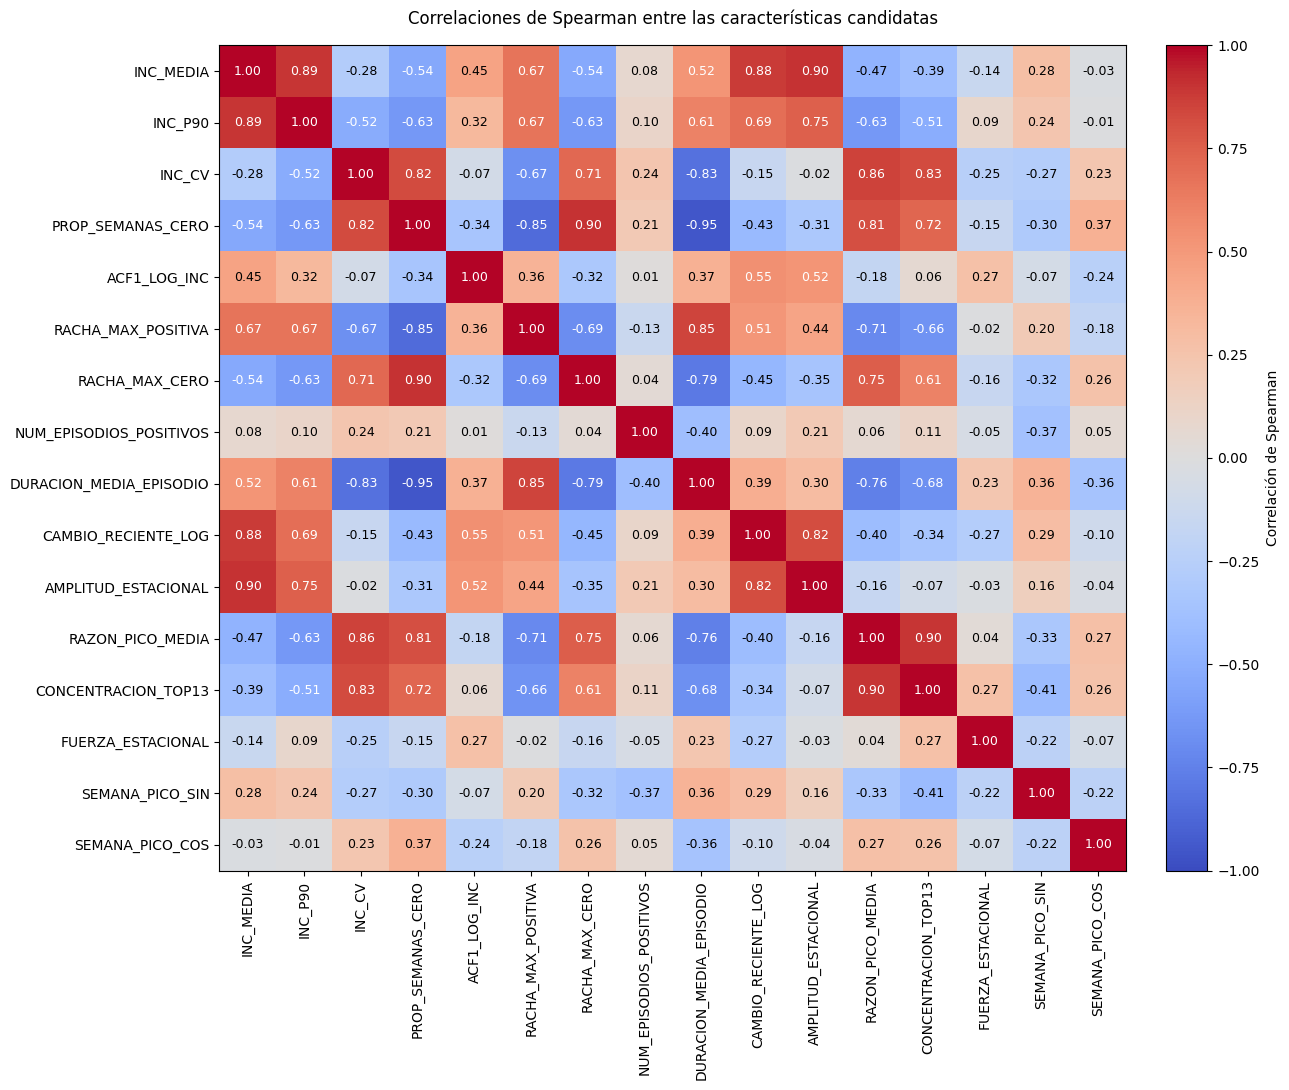

In [8]:
FIGURES_DIR = (
    BASE_DIR
    / "figuras"
    / "05_features_clustering"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)




fig, ax = plt.subplots(figsize=(13, 11))

imagen = ax.imshow(
    corr_spearman,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="auto"
)

ax.set_xticks(np.arange(len(columnas_candidatas)))
ax.set_yticks(np.arange(len(columnas_candidatas)))

ax.set_xticklabels(columnas_candidatas, rotation=90)
ax.set_yticklabels(columnas_candidatas)

ax.set_title(
    "Correlaciones de Spearman entre las características candidatas",
    pad=15
)


matriz_corr = np.array(corr_spearman)

for i in range(len(columnas_candidatas)):
    for j in range(len(columnas_candidatas)):
        valor = matriz_corr[i, j]
        
        # Usamos texto blanco para valores extremos (oscuros) y negro para los centrales (claros)
        color_texto = "white" if abs(valor) > 0.5 else "black"
        
        ax.text(
            j, i, 
            f"{valor:.2f}", # Muestra solo 2 decimales
            ha="center", 
            va="center", 
            color=color_texto,
            fontsize=9 # Ajusta este tamaño si los números se ven muy grandes o pequeños
        )


barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

barra.set_label("Correlación de Spearman")

fig.tight_layout()

RUTA_FIG_CORRELACION = (
    FIGURES_DIR
    / "fig_01_correlacion_features_candidatas.png"
)

fig.savefig(
    RUTA_FIG_CORRELACION,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El diagnóstico confirma cuatro bloques redundantes: magnitud, intermitencia, duración de episodios y concentración estacional. Para mantener una representación adecuada con sólo 32 estados, reduciremos las 16 variables a 10 características, conservando información de intensidad, irregularidad, persistencia, cambio temporal y estacionalidad.

## 7. Selección parsimoniosa y estandarización de las características

El diagnóstico de correlación mostró que varias características describen dimensiones epidemiológicas muy similares. En particular, se identificaron asociaciones elevadas entre:

- incidencia media, percentil 90 y amplitud estacional;
- proporción de semanas sin casos, duración media de los episodios y longitud de las rachas;
- razón pico-media y concentración en las semanas de mayor actividad;
- incidencia media y cambio reciente.

Debido a que sólo se dispone de 32 entidades federativas, mantener un número excesivo de variables podría provocar que algunas dimensiones tengan una influencia desproporcionada en el clustering.

Se seleccionará una representación final de diez características:

| Dimensión | Característica seleccionada | Interpretación |
|---|---|---|
| Intensidad | `INC_P90` | Nivel de incidencia durante semanas de actividad alta |
| Variabilidad | `INC_CV` | Variabilidad relativa de la trayectoria |
| Intermitencia | `PROP_SEMANAS_CERO` | Frecuencia de semanas sin casos |
| Persistencia | `ACF1_LOG_INC` | Dependencia entre semanas consecutivas |
| Fragmentación | `NUM_EPISODIOS_POSITIVOS` | Número de periodos separados con actividad |
| Cambio temporal | `CAMBIO_RECIENTE_LOG` | Diferencia entre 2023--2025 y 2020--2022 |
| Concentración estacional | `CONCENTRACION_TOP13` | Proporción de actividad concentrada en 13 semanas |
| Fuerza estacional | `FUERZA_ESTACIONAL` | Variabilidad explicada por la semana del año |
| Momento del pico | `SEMANA_PICO_SIN` | Componente circular seno |
| Momento del pico | `SEMANA_PICO_COS` | Componente circular coseno |

Se utiliza el percentil 90 en lugar de la incidencia media porque representa la intensidad durante periodos de actividad elevada y presenta menor redundancia con el cambio reciente.

Antes de estandarizar se aplicará la transformación

$$
x^\ast=\log(1+x)
$$

al percentil 90, al coeficiente de variación y al número de episodios positivos. Esta transformación reduce la influencia de valores extremos, conservando el orden relativo de los estados.

Finalmente, todas las características se estandarizarán mediante

$$
z_{ij}=
\frac{x_{ij}-\overline{x}_j}{s_j}.
$$

La matriz estandarizada será la entrada para el análisis de componentes principales y el clustering exploratorio.

In [9]:
# Selección parsimoniosa y estandarización de características


from sklearn.preprocessing import StandardScaler


# Características finales en su escala original
columnas_finales_originales = [
    "INC_P90",
    "INC_CV",
    "PROP_SEMANAS_CERO",
    "ACF1_LOG_INC",
    "NUM_EPISODIOS_POSITIVOS",
    "CAMBIO_RECIENTE_LOG",
    "CONCENTRACION_TOP13",
    "FUERZA_ESTACIONAL",
    "SEMANA_PICO_SIN",
    "SEMANA_PICO_COS"
]

features_finales_originales = (
    features_completas[
        columnas_finales_originales
    ]
    .copy()
    .sort_index()
)



# Transformaciones previas

features_finales_transformadas = pd.DataFrame(
    index=features_finales_originales.index
)

features_finales_transformadas.index.name = "ESTADO"

features_finales_transformadas["LOG1P_INC_P90"] = np.log1p(
    features_finales_originales["INC_P90"]
)

features_finales_transformadas["LOG1P_INC_CV"] = np.log1p(
    features_finales_originales["INC_CV"]
)

features_finales_transformadas["PROP_SEMANAS_CERO"] = (
    features_finales_originales["PROP_SEMANAS_CERO"]
)

features_finales_transformadas["ACF1_LOG_INC"] = (
    features_finales_originales["ACF1_LOG_INC"]
)

features_finales_transformadas[
    "LOG1P_NUM_EPISODIOS_POSITIVOS"
] = np.log1p(
    features_finales_originales[
        "NUM_EPISODIOS_POSITIVOS"
    ]
)

features_finales_transformadas["CAMBIO_RECIENTE_LOG"] = (
    features_finales_originales["CAMBIO_RECIENTE_LOG"]
)

features_finales_transformadas["CONCENTRACION_TOP13"] = (
    features_finales_originales["CONCENTRACION_TOP13"]
)

features_finales_transformadas["FUERZA_ESTACIONAL"] = (
    features_finales_originales["FUERZA_ESTACIONAL"]
)

features_finales_transformadas["SEMANA_PICO_SIN"] = (
    features_finales_originales["SEMANA_PICO_SIN"]
)

features_finales_transformadas["SEMANA_PICO_COS"] = (
    features_finales_originales["SEMANA_PICO_COS"]
)


# Validaciones

assert features_finales_originales.shape == (32, 10)
assert features_finales_transformadas.shape == (32, 10)

assert (
    features_finales_transformadas
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    features_finales_transformadas.to_numpy()
).all()



# Correlación de las características seleccionadas

corr_final = (
    features_finales_transformadas
    .corr(method="pearson")
)

pares_finales = []

columnas_transformadas = (
    features_finales_transformadas.columns.tolist()
)

for i, variable_1 in enumerate(
    columnas_transformadas
):

    for variable_2 in columnas_transformadas[
        i + 1:
    ]:

        correlacion = corr_final.loc[
            variable_1,
            variable_2
        ]

        pares_finales.append(
            {
                "VARIABLE_1": variable_1,
                "VARIABLE_2": variable_2,
                "CORRELACION": correlacion,
                "CORRELACION_ABS": abs(correlacion)
            }
        )


pares_finales = (
    pd.DataFrame(pares_finales)
    .sort_values(
        "CORRELACION_ABS",
        ascending=False
    )
    .reset_index(drop=True)
)


UMBRAL_FINAL = 0.85

pares_finales_altos = (
    pares_finales.loc[
        pares_finales["CORRELACION_ABS"]
        >= UMBRAL_FINAL
    ]
    .copy()
)


print(
    "Características seleccionadas para el análisis:"
)

display(
    features_finales_transformadas.round(4)
)


print(
    "\nPares con correlación absoluta "
    f"mayor o igual que {UMBRAL_FINAL}:"
)

if pares_finales_altos.empty:

    print(
        "No se identificaron pares por encima del umbral."
    )

else:

    display(
        pares_finales_altos.round(4)
    )


print(
    "\nDiez pares con mayor correlación absoluta:"
)

display(
    pares_finales.head(10).round(4)
)



# Estandarización


escalador = StandardScaler()

matriz_estandarizada = escalador.fit_transform(
    features_finales_transformadas
)

features_estandarizadas = pd.DataFrame(
    matriz_estandarizada,
    index=features_finales_transformadas.index,
    columns=features_finales_transformadas.columns
)

features_estandarizadas.index.name = "ESTADO"



# Verificación del escalamiento

resumen_estandarizacion = pd.DataFrame(
    {
        "MEDIA": features_estandarizadas.mean(axis=0),
        "DESV_EST_POBLACIONAL": (
            features_estandarizadas.std(
                axis=0,
                ddof=0
            )
        ),
        "MIN": features_estandarizadas.min(axis=0),
        "MAX": features_estandarizadas.max(axis=0)
    }
)

print(
    "\nVerificación de la matriz estandarizada:"
)

display(
    resumen_estandarizacion.round(6)
)




Características seleccionadas para el análisis:


,LOG1P_INC_P90,LOG1P_INC_CV,PROP_SEMANAS_CERO,ACF1_LOG_INC,LOG1P_NUM_EPISODIOS_POSITIVOS,CAMBIO_RECIENTE_LOG,CONCENTRACION_TOP13,FUERZA_ESTACIONAL,SEMANA_PICO_SIN,SEMANA_PICO_COS
ESTADO,,,,,,,,,,
AGUASCALIENTES,0.4245,1.6104,0.7596,0.9762,2.8332,0.9304,0.9073,0.2201,-0.9709,0.2393
BAJA CALIFORNIA,0.0493,1.3514,0.7340,0.5580,3.2581,0.0223,0.7914,0.2861,-0.9709,0.2393
BAJA CALIFORNIA SUR,1.6629,1.2154,0.4712,0.9524,3.4012,1.2528,0.7075,0.2919,-0.8855,0.4647
CAMPECHE,0.9869,1.4736,0.4423,0.9460,3.6376,0.9118,0.6755,0.1170,-0.9709,-0.2393
CHIAPAS,1.0122,0.9382,0.0833,0.9680,2.7726,0.4891,0.5331,0.2600,-0.8230,-0.5681
CHIHUAHUA,0.0250,1.7738,0.8462,0.8964,3.0445,0.0352,0.9389,0.2186,-0.9927,0.1205
COAHUILA,1.2712,1.2955,0.5897,0.9630,3.0445,0.3795,0.8564,0.5784,-0.8855,0.4647
COLIMA,2.0551,1.2103,0.2051,0.9523,3.2958,1.2969,0.5426,0.1185,-0.9709,-0.2393
DISTRITO FEDERAL,0.0620,1.1260,0.5801,0.7574,3.8918,0.0323,0.5782,0.1849,-0.9927,0.1205



Pares con correlación absoluta mayor o igual que 0.85:
No se identificaron pares por encima del umbral.

Diez pares con mayor correlación absoluta:


,VARIABLE_1,VARIABLE_2,CORRELACION,CORRELACION_ABS
0,LOG1P_INC_CV,PROP_SEMANAS_CERO,0.8305,0.8305
1,LOG1P_INC_CV,CONCENTRACION_TOP13,0.8202,0.8202
2,PROP_SEMANAS_CERO,CONCENTRACION_TOP13,0.7572,0.7572
3,LOG1P_INC_P90,CAMBIO_RECIENTE_LOG,0.7314,0.7314
4,LOG1P_INC_P90,PROP_SEMANAS_CERO,-0.7153,0.7153
5,LOG1P_INC_P90,LOG1P_INC_CV,-0.5644,0.5644
6,LOG1P_INC_P90,CONCENTRACION_TOP13,-0.5387,0.5387
7,PROP_SEMANAS_CERO,ACF1_LOG_INC,-0.5205,0.5205
8,LOG1P_INC_P90,ACF1_LOG_INC,0.5149,0.5149
9,ACF1_LOG_INC,CAMBIO_RECIENTE_LOG,0.4539,0.4539



Verificación de la matriz estandarizada:


,MEDIA,DESV_EST_POBLACIONAL,MIN,MAX
LOG1P_INC_P90,0.0000,1.0000,-1.6098,1.9521
LOG1P_INC_CV,-0.0000,1.0000,-1.4714,2.2879
PROP_SEMANAS_CERO,0.0000,1.0000,-1.3667,2.0137
ACF1_LOG_INC,0.0000,1.0000,-4.4574,0.4858
LOG1P_NUM_EPISODIOS_POSITIVOS,0.0000,1.0000,-2.9757,2.2994
CAMBIO_RECIENTE_LOG,-0.0000,1.0000,-1.3601,2.0386
CONCENTRACION_TOP13,0.0000,1.0000,-1.9272,1.8611
FUERZA_ESTACIONAL,-0.0000,1.0000,-1.3246,2.8625
SEMANA_PICO_SIN,-0.0000,1.0000,-0.5193,3.9023
SEMANA_PICO_COS,0.0000,1.0000,-2.1148,2.2348


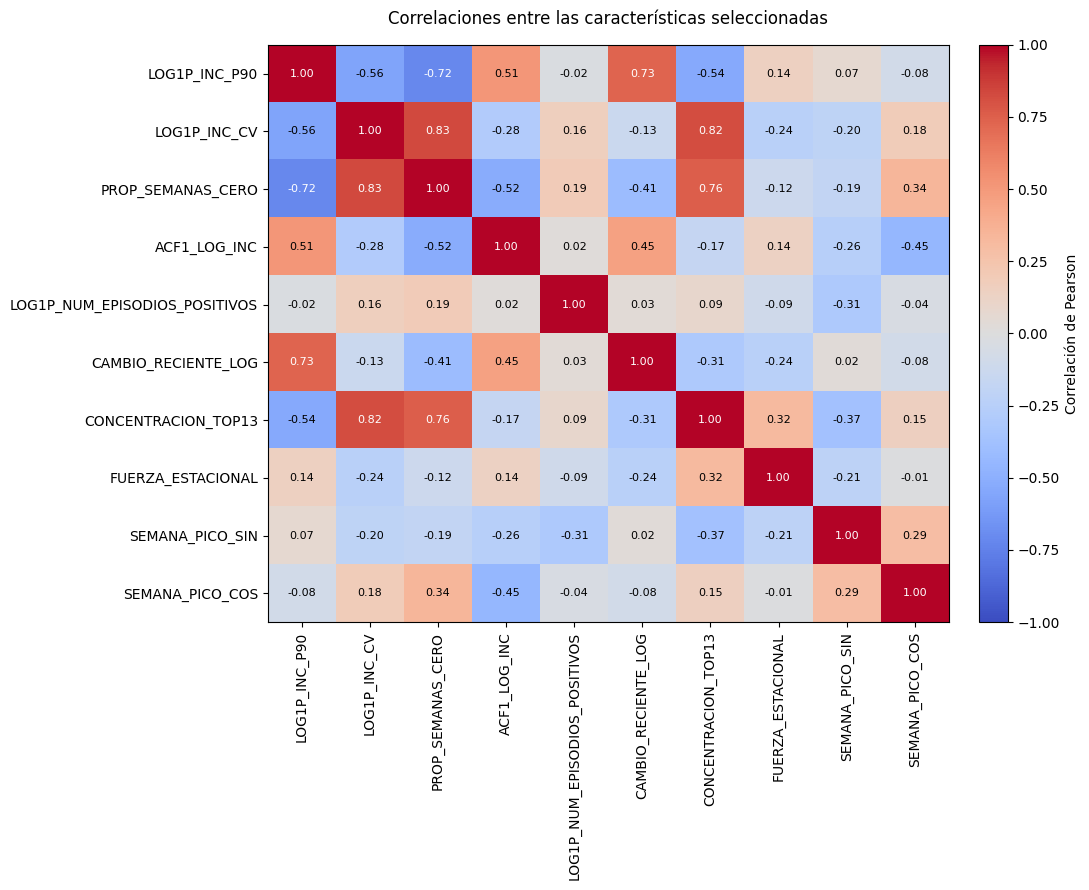

In [10]:
# Mapa de calor de correlaciones finales

fig, ax = plt.subplots(
    figsize=(11, 9)
)

imagen = ax.imshow(
    corr_final,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(columnas_transformadas))
)

ax.set_yticks(
    np.arange(len(columnas_transformadas))
)

ax.set_xticklabels(
    columnas_transformadas,
    rotation=90
)

ax.set_yticklabels(
    columnas_transformadas
)

for i in range(len(columnas_transformadas)):

    for j in range(len(columnas_transformadas)):

        valor = corr_final.iloc[i, j]

        color_texto = (
            "white"
            if abs(valor) >= 0.60
            else "black"
        )

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            color=color_texto,
            fontsize=8
        )

ax.set_title(
    "Correlaciones entre las características seleccionadas",
    pad=15
)

barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

barra.set_label(
    "Correlación de Pearson"
)

fig.tight_layout()


RUTA_FIG_CORRELACION_FINAL = (
    FIGURES_DIR
    / "fig_02_correlacion_features_seleccionadas.png"
)

fig.savefig(
    RUTA_FIG_CORRELACION_FINAL,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Guardar matrices

RUTA_FEATURES_FINALES_ORIGINALES = (
    FEATURES_DIR
    / "features_finales_originales_2020_2025.csv"
)

RUTA_FEATURES_FINALES_TRANSFORMADAS = (
    FEATURES_DIR
    / "features_finales_transformadas_2020_2025.csv"
)

RUTA_FEATURES_ESTANDARIZADAS = (
    FEATURES_DIR
    / "features_finales_estandarizadas_2020_2025.csv"
)


features_finales_originales.to_csv(
    RUTA_FEATURES_FINALES_ORIGINALES,
    encoding="utf-8-sig"
)

features_finales_transformadas.to_csv(
    RUTA_FEATURES_FINALES_TRANSFORMADAS,
    encoding="utf-8-sig"
)

features_estandarizadas.to_csv(
    RUTA_FEATURES_ESTANDARIZADAS,
    encoding="utf-8-sig"
)


## 8. Análisis de componentes principales

La matriz seleccionada contiene diez características estandarizadas para las 32 entidades federativas. Aunque este número de variables es manejable, resulta útil obtener una representación de menor dimensión que permita visualizar similitudes y diferencias entre los estados.

Se aplicará un análisis de componentes principales (PCA) sobre la matriz estandarizada. Cada componente principal es una combinación lineal de las características originales:

$$
PC_k=
a_{k1}Z_1+\cdots+a_{kp}Z_p,
$$

donde $Z_1,\ldots,Z_p$ representan las características estandarizadas y los coeficientes $a_{kj}$ determinan la contribución de cada variable.

El análisis tendrá tres propósitos:

1. cuantificar cuánta variabilidad puede resumirse mediante un número reducido de componentes;
2. identificar las características que explican las principales diferencias entre estados;
3. visualizar la posición relativa de las entidades en el plano formado por los dos primeros componentes.

La orientación de los componentes es arbitraria: el signo de un componente puede invertirse sin modificar su interpretación geométrica. Por ello, la interpretación se basará en la magnitud y relación entre las cargas, no únicamente en su signo.

El PCA se utilizará como herramienta descriptiva y de visualización. El clustering posterior continuará utilizando la matriz completa de características estandarizadas, salvo que los resultados indiquen una reducción dimensional claramente conveniente.

In [11]:
# Análisis de componentes principales
from sklearn.decomposition import PCA


# Ajuste del PCA

pca = PCA()

coordenadas_pca = pca.fit_transform(
    features_estandarizadas
)

n_componentes = len(
    pca.explained_variance_ratio_
)


# Varianza explicada

tabla_varianza_pca = pd.DataFrame(
    {
        "COMPONENTE": [
            f"PC{i}"
            for i in range(1, n_componentes + 1)
        ],
        "VARIANZA_EXPLICADA": (
            pca.explained_variance_ratio_
        ),
        "VARIANZA_ACUMULADA": (
            np.cumsum(
                pca.explained_variance_ratio_
            )
        ),
        "VALOR_PROPIO": (
            pca.explained_variance_
        )
    }
)

print(
    "Varianza explicada por los componentes principales:"
)

display(
    tabla_varianza_pca.round(4)
)


# Número mínimo de componentes para alcanzar ciertos umbrales

umbrales = [
    0.60,
    0.70,
    0.80,
    0.90
]

componentes_por_umbral = []

for umbral in umbrales:

    numero = int(
        np.argmax(
            tabla_varianza_pca[
                "VARIANZA_ACUMULADA"
            ].to_numpy()
            >= umbral
        )
        + 1
    )

    componentes_por_umbral.append(
        {
            "UMBRAL_VAR_ACUMULADA": umbral,
            "NUM_COMPONENTES": numero
        }
    )

tabla_umbrales_pca = pd.DataFrame(
    componentes_por_umbral
)

print(
    "\nNúmero de componentes necesarios "
    "para alcanzar distintos niveles de varianza:"
)

display(
    tabla_umbrales_pca
)


# Coordenadas de los estados

columnas_pc = [
    f"PC{i}"
    for i in range(1, n_componentes + 1)
]

scores_pca = pd.DataFrame(
    coordenadas_pca,
    index=features_estandarizadas.index,
    columns=columnas_pc
)

scores_pca.index.name = "ESTADO"



# Cargas de los componentes


# Las cargas se calculan como: componente × raíz del valor propio
# Para datos estandarizados pueden interpretarse como
# aproximaciones a las correlaciones entre las variables
# originales y los componentes.

cargas_pca = pd.DataFrame(
    pca.components_.T
    * np.sqrt(
        pca.explained_variance_
    ),
    index=features_estandarizadas.columns,
    columns=columnas_pc
)

cargas_pca.index.name = "CARACTERISTICA"


print(
    "\nCargas de las características "
    "en los tres primeros componentes:"
)

display(
    cargas_pca[
        ["PC1", "PC2", "PC3"]
    ].round(4)
)



# Variables con mayor contribución absoluta

resumen_cargas = []

for componente in [
    "PC1",
    "PC2",
    "PC3"
]:

    ordenadas = (
        cargas_pca[componente]
        .sort_values(
            key=np.abs,
            ascending=False
        )
    )

    for posicion, (
        variable,
        carga
    ) in enumerate(
        ordenadas.head(5).items(),
        start=1
    ):

        resumen_cargas.append(
            {
                "COMPONENTE": componente,
                "POSICION": posicion,
                "CARACTERISTICA": variable,
                "CARGA": carga,
                "CARGA_ABS": abs(carga)
            }
        )


tabla_cargas_principales = pd.DataFrame(
    resumen_cargas
)

print(
    "\nCinco características con mayor carga absoluta "
    "en cada uno de los tres primeros componentes:"
)

display(
    tabla_cargas_principales.round(4)
)


# Abreviaturas 
abreviaturas_estados = {
    "AGUASCALIENTES": "AGS",
    "BAJA CALIFORNIA": "BC",
    "BAJA CALIFORNIA SUR": "BCS",
    "CAMPECHE": "CAMP",
    "CHIAPAS": "CHIS",
    "CHIHUAHUA": "CHIH",
    "COAHUILA": "COAH",
    "COLIMA": "COL",
    "DISTRITO FEDERAL": "CDMX",
    "DURANGO": "DGO",
    "GUANAJUATO": "GTO",
    "GUERRERO": "GRO",
    "HIDALGO": "HGO",
    "JALISCO": "JAL",
    "MEXICO": "MEX",
    "MICHOACAN": "MICH",
    "MORELOS": "MOR",
    "NAYARIT": "NAY",
    "NUEVO LEON": "NL",
    "OAXACA": "OAX",
    "PUEBLA": "PUE",
    "QUERETARO": "QRO",
    "QUINTANA ROO": "QROO",
    "SAN LUIS POTOSI": "SLP",
    "SINALOA": "SIN",
    "SONORA": "SON",
    "TABASCO": "TAB",
    "TAMAULIPAS": "TAMPS",
    "TLAXCALA": "TLAX",
    "VERACRUZ": "VER",
    "YUCATAN": "YUC",
    "ZACATECAS": "ZAC"
}

scores_pca["ABREVIATURA"] = (
    scores_pca.index
    .to_series()
    .map(abreviaturas_estados)
)

assert scores_pca[
    "ABREVIATURA"
].notna().all()



Varianza explicada por los componentes principales:


,COMPONENTE,VARIANZA_EXPLICADA,VARIANZA_ACUMULADA,VALOR_PROPIO
0,PC1,0.3791,0.3791,3.9136
1,PC2,0.1838,0.5629,1.8970
2,PC3,0.1388,0.7017,1.4326
3,PC4,0.1053,0.8069,1.0867
4,PC5,0.0904,0.8973,0.9327
5,PC6,0.0448,0.9421,0.4622
6,PC7,0.0357,0.9778,0.3683
7,PC8,0.0108,0.9885,0.1110
8,PC9,0.0100,0.9986,0.1036
9,PC10,0.0014,1.0000,0.0149



Número de componentes necesarios para alcanzar distintos niveles de varianza:


,UMBRAL_VAR_ACUMULADA,NUM_COMPONENTES
0,0.6000,3
1,0.7000,3
2,0.8000,4
3,0.9000,6



Cargas de las características en los tres primeros componentes:


,PC1,PC2,PC3
CARACTERISTICA,,,
LOG1P_INC_P90,-0.8580,-0.1167,-0.1441
LOG1P_INC_CV,0.8348,-0.2009,-0.3867
PROP_SEMANAS_CERO,0.9564,-0.0330,-0.1717
ACF1_LOG_INC,-0.6064,-0.5989,-0.0426
LOG1P_NUM_EPISODIOS_POSITIVOS,0.1535,-0.4076,-0.4213
CAMBIO_RECIENTE_LOG,-0.5999,-0.1717,-0.6120
CONCENTRACION_TOP13,0.8173,-0.4190,0.1102
FUERZA_ESTACIONAL,-0.0378,-0.3446,0.8108
SEMANA_PICO_SIN,-0.1832,0.8404,-0.0334



Cinco características con mayor carga absoluta en cada uno de los tres primeros componentes:


,COMPONENTE,POSICION,CARACTERISTICA,CARGA,CARGA_ABS
0,PC1,1,PROP_SEMANAS_CERO,0.9564,0.9564
1,PC1,2,LOG1P_INC_P90,-0.8580,0.8580
2,PC1,3,LOG1P_INC_CV,0.8348,0.8348
3,PC1,4,CONCENTRACION_TOP13,0.8173,0.8173
4,PC1,5,ACF1_LOG_INC,-0.6064,0.6064
5,PC2,1,SEMANA_PICO_SIN,0.8404,0.8404
6,PC2,2,ACF1_LOG_INC,-0.5989,0.5989
7,PC2,3,SEMANA_PICO_COS,0.5359,0.5359
8,PC2,4,CONCENTRACION_TOP13,-0.4190,0.4190
9,PC2,5,LOG1P_NUM_EPISODIOS_POSITIVOS,-0.4076,0.4076


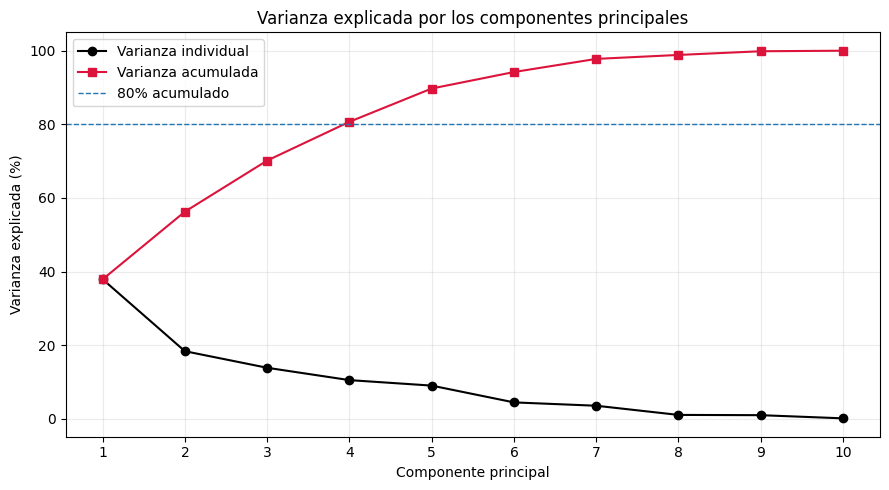

In [12]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

componentes = np.arange(
    1,
    n_componentes + 1
)

ax.plot(
    componentes,
    100
    * pca.explained_variance_ratio_,
    marker="o",
    label="Varianza individual", color='black'
)

ax.plot(
    componentes,
    100
    * np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker="s",
    label="Varianza acumulada", color = 'crimson'
)

ax.axhline(
    80,
    linestyle="--",
    linewidth=1,
    label="80% acumulado"
)

ax.set_xticks(
    componentes
)

ax.set_xlabel(
    "Componente principal"
)

ax.set_ylabel(
    "Varianza explicada (%)"
)

ax.set_title(
    "Varianza explicada por los componentes principales"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


RUTA_FIG_VAR_PCA = (
    FIGURES_DIR
    / "fig_03_varianza_explicada_pca.png"
)

fig.savefig(
    RUTA_FIG_VAR_PCA,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

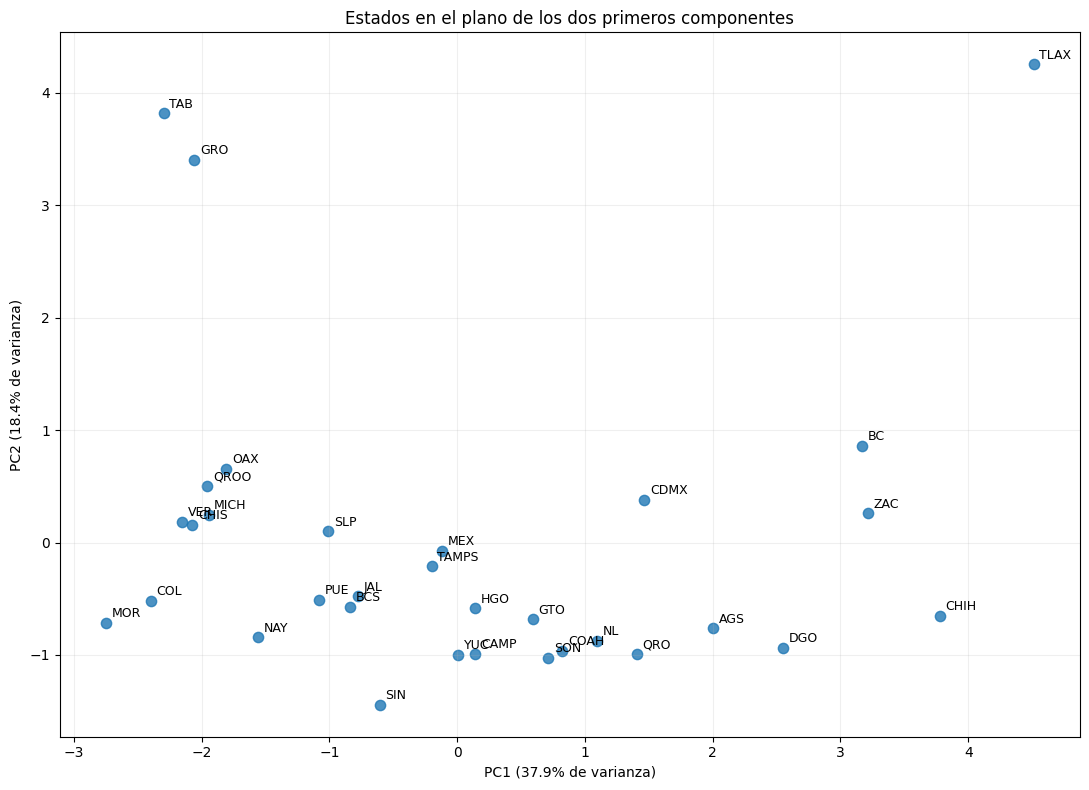

In [13]:
var_pc1 = (
    100
    * pca.explained_variance_ratio_[0]
)

var_pc2 = (
    100
    * pca.explained_variance_ratio_[1]
)


fig, ax = plt.subplots(
    figsize=(11, 8)
)

ax.scatter(
    scores_pca["PC1"],
    scores_pca["PC2"],
    s=55,
    alpha=0.80
)

for estado, fila in scores_pca.iterrows():

    ax.annotate(
        fila["ABREVIATURA"],
        (
            fila["PC1"],
            fila["PC2"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9
    )



ax.set_xlabel(
    f"PC1 ({var_pc1:.1f}% de varianza)"
)

ax.set_ylabel(
    f"PC2 ({var_pc2:.1f}% de varianza)"
)

ax.set_title(
    "Estados en el plano de los dos primeros componentes"
)

ax.grid(
    alpha=0.20
)

fig.tight_layout()


RUTA_FIG_PCA_ESTADOS = (
    FIGURES_DIR
    / "fig_04_estados_plano_pca.png"
)

fig.savefig(
    RUTA_FIG_PCA_ESTADOS,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Estados más alejados del centro del plano PC1--PC2
scores_pca[
    "DISTANCIA_PC1_PC2"
] = np.sqrt(
    scores_pca["PC1"] ** 2
    + scores_pca["PC2"] ** 2
)

estados_extremos_pca = (
    scores_pca[
        [
            "PC1",
            "PC2",
            "DISTANCIA_PC1_PC2"
        ]
    ]
    .sort_values(
        "DISTANCIA_PC1_PC2",
        ascending=False
    )
    .head(10)
)

print(
    "\nDiez estados más alejados del centro "
    "en el plano PC1--PC2:"
)

display(
    estados_extremos_pca.round(4)
)




RUTA_VAR_PCA = (
    FEATURES_DIR
    / "varianza_explicada_pca_2020_2025.csv"
)

RUTA_CARGAS_PCA = (
    FEATURES_DIR
    / "cargas_pca_2020_2025.csv"
)

RUTA_SCORES_PCA = (
    FEATURES_DIR
    / "coordenadas_estados_pca_2020_2025.csv"
)


tabla_varianza_pca.to_csv(
    RUTA_VAR_PCA,
    index=False,
    encoding="utf-8-sig"
)

cargas_pca.to_csv(
    RUTA_CARGAS_PCA,
    encoding="utf-8-sig"
)

scores_pca.to_csv(
    RUTA_SCORES_PCA,
    encoding="utf-8-sig"
)



Diez estados más alejados del centro en el plano PC1--PC2:


,PC1,PC2,DISTANCIA_PC1_PC2
ESTADO,,,
TLAXCALA,4.5115,4.2514,6.1990
TABASCO,-2.2978,3.8156,4.4541
GUERRERO,-2.0560,3.4037,3.9765
CHIHUAHUA,3.7795,-0.6499,3.8350
BAJA CALIFORNIA,3.1667,0.8602,3.2814
ZACATECAS,3.2129,0.2600,3.2234
MORELOS,-2.7470,-0.7120,2.8378
DURANGO,2.5526,-0.9379,2.7194
COLIMA,-2.3997,-0.5171,2.4548


## 9. Clustering jerárquico exploratorio

El análisis de componentes principales mostró que las entidades federativas presentan diferencias importantes en intensidad, persistencia, concentración estacional y momento del pico epidemiológico.

Como primera aproximación al agrupamiento se utilizará clustering jerárquico aglomerativo con el método de Ward. Este procedimiento comienza considerando cada estado como un grupo independiente y fusiona progresivamente los grupos que producen el menor incremento en la variabilidad interna.

El método de Ward utiliza distancia euclidiana y resulta apropiado para variables previamente estandarizadas. El resultado se representará mediante un dendrograma, el cual permitirá identificar posibles niveles de agrupamiento sin fijar anticipadamente el número de clústeres.

También se evaluarán particiones con

$$
k=2,3,4,5,6
$$

mediante tres criterios internos:

- **coeficiente silhouette**, para el cual valores mayores indican grupos más separados;
- **índice de Calinski--Harabasz**, para el cual valores mayores son preferibles;
- **índice de Davies--Bouldin**, para el cual valores menores indican una mejor partición.

Estos criterios se utilizarán únicamente para identificar valores plausibles de $k$. La selección definitiva deberá considerar posteriormente la estabilidad de las particiones y su interpretación epidemiológica.

Debido a que esta etapa corresponde al primer trimestre de avances, los resultados se presentarán como un clustering exploratorio y no como la clasificación final de los estados.

In [15]:
# Clustering jerárquico exploratorio


# Matriz utilizada para el clustering
X_cluster = features_estandarizadas.to_numpy()

estados_cluster = (
    features_estandarizadas
    .index
    .tolist()
)

etiquetas_dendrograma = [
    abreviaturas_estados[estado]
    for estado in estados_cluster
]



# Matriz de enlace de Ward
matriz_enlace_ward = linkage(
    X_cluster,
    method="ward",
    metric="euclidean"
)



# Correlación cofenética


# Mide qué tan bien el dendrograma reproduce las distancias
# originales entre los estados.

distancias_originales = pdist(
    X_cluster,
    metric="euclidean"
)

correlacion_cofenetica, _ = cophenet(
    matriz_enlace_ward,
    distancias_originales
)

print(
    "Correlación cofenética del dendrograma:"
)

print(
    f"{correlacion_cofenetica:.4f}"
)



# Evaluación de distintos números de clústeres


resultados_clustering = []

asignaciones_jerarquicas = pd.DataFrame(
    index=features_estandarizadas.index
)

asignaciones_jerarquicas.index.name = "ESTADO"


for k in range(2, 7):

    modelo = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    etiquetas = modelo.fit_predict(
        X_cluster
    )

    # Las etiquetas de sklearn comienzan en cero.
    etiquetas = etiquetas + 1

    asignaciones_jerarquicas[
        f"CLUSTER_K{k}"
    ] = etiquetas

    tamanos = (
        pd.Series(etiquetas)
        .value_counts()
        .sort_index()
    )

    resultados_clustering.append(
        {
            "K": k,
            "SILHOUETTE": silhouette_score(
                X_cluster,
                etiquetas
            ),
            "CALINSKI_HARABASZ": (
                calinski_harabasz_score(
                    X_cluster,
                    etiquetas
                )
            ),
            "DAVIES_BOULDIN": (
                davies_bouldin_score(
                    X_cluster,
                    etiquetas
                )
            ),
            "TAMANO_MINIMO": int(
                tamanos.min()
            ),
            "TAMANO_MAXIMO": int(
                tamanos.max()
            ),
            "TAMANOS_CLUSTERS": " | ".join(
                [
                    f"C{cluster}:{tamano}"
                    for cluster, tamano
                    in tamanos.items()
                ]
            )
        }
    )


tabla_metricas_jerarquico = pd.DataFrame(
    resultados_clustering
)


print(
    "\nMétricas internas para distintos "
    "números de clústeres:"
)

display(
    tabla_metricas_jerarquico.round(4)
)

Correlación cofenética del dendrograma:
0.6381

Métricas internas para distintos números de clústeres:


,K,SILHOUETTE,CALINSKI_HARABASZ,DAVIES_BOULDIN,TAMANO_MINIMO,TAMANO_MAXIMO,TAMANOS_CLUSTERS
0,2,0.2728,10.2930,1.3445,7,25,C1:25 | C2:7
1,3,0.2691,8.8547,1.1358,2,23,C1:23 | C2:7 | C3:2
2,4,0.2215,8.7395,1.2590,2,16,C1:16 | C2:7 | C3:2 | C4:7
3,5,0.2124,9.1856,1.1783,2,9,C1:7 | C2:7 | C3:2 | C4:7 | C5:9
4,6,0.2384,9.9421,1.0665,2,9,C1:3 | C2:7 | C3:4 | C4:7 | C5:9 | C6:2


In [16]:
# Mejor valor de k según cada criterio

mejor_silhouette = int(
    tabla_metricas_jerarquico.loc[
        tabla_metricas_jerarquico[
            "SILHOUETTE"
        ].idxmax(),
        "K"
    ]
)

mejor_calinski = int(
    tabla_metricas_jerarquico.loc[
        tabla_metricas_jerarquico[
            "CALINSKI_HARABASZ"
        ].idxmax(),
        "K"
    ]
)

mejor_davies = int(
    tabla_metricas_jerarquico.loc[
        tabla_metricas_jerarquico[
            "DAVIES_BOULDIN"
        ].idxmin(),
        "K"
    ]
)


resumen_mejores_k = pd.DataFrame(
    {
        "CRITERIO": [
            "Silhouette",
            "Calinski--Harabasz",
            "Davies--Bouldin"
        ],
        "MEJOR_K": [
            mejor_silhouette,
            mejor_calinski,
            mejor_davies
        ]
    }
)


print(
    "\nNúmero de clústeres preferido "
    "por cada criterio:"
)

display(
    resumen_mejores_k
)


Número de clústeres preferido por cada criterio:


,CRITERIO,MEJOR_K
0,Silhouette,2
1,Calinski--Harabasz,2
2,Davies--Bouldin,6


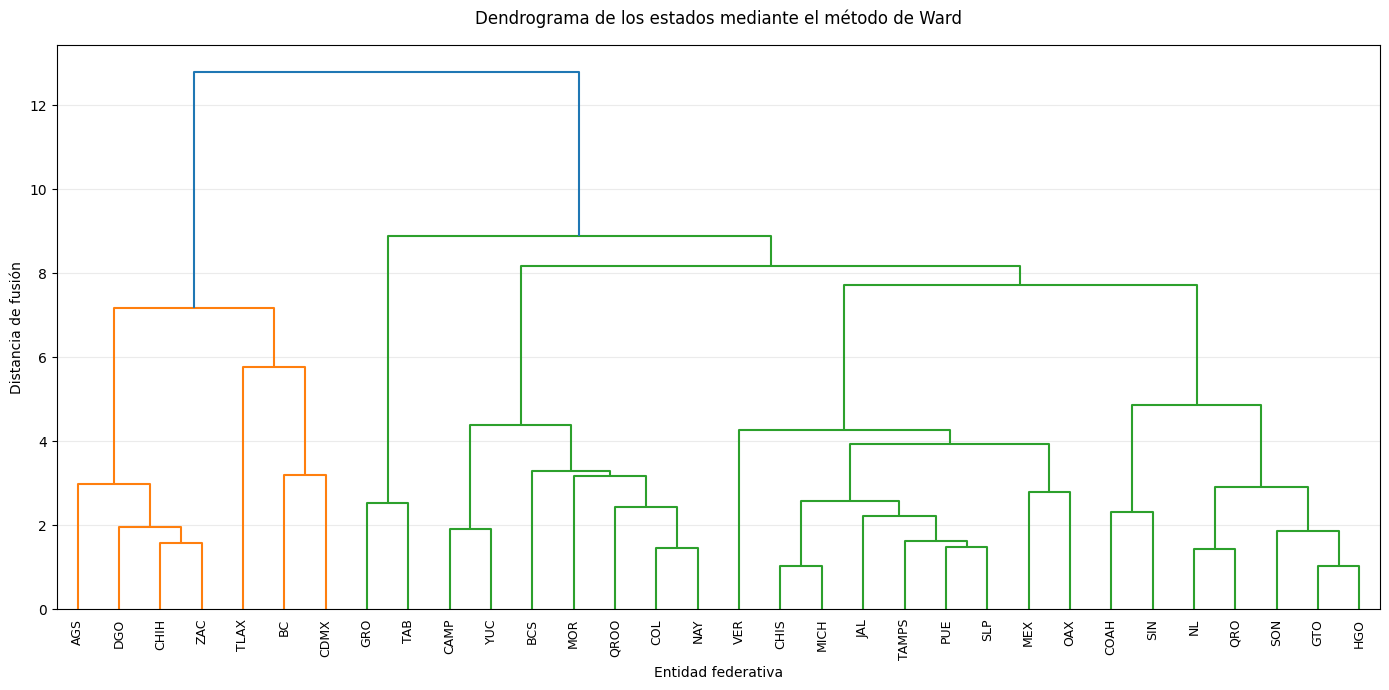

In [17]:
# Dendrograma

fig, ax = plt.subplots(
    figsize=(14, 7)
)

dendrograma = dendrogram(
    matriz_enlace_ward,
    labels=etiquetas_dendrograma,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax
)

ax.set_title(
    "Dendrograma de los estados mediante el método de Ward",
    pad=15
)

ax.set_xlabel(
    "Entidad federativa"
)

ax.set_ylabel(
    "Distancia de fusión"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()


RUTA_FIG_DENDROGRAMA = (
    FIGURES_DIR
    / "fig_05_dendrograma_ward_estados.png"
)

fig.savefig(
    RUTA_FIG_DENDROGRAMA,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

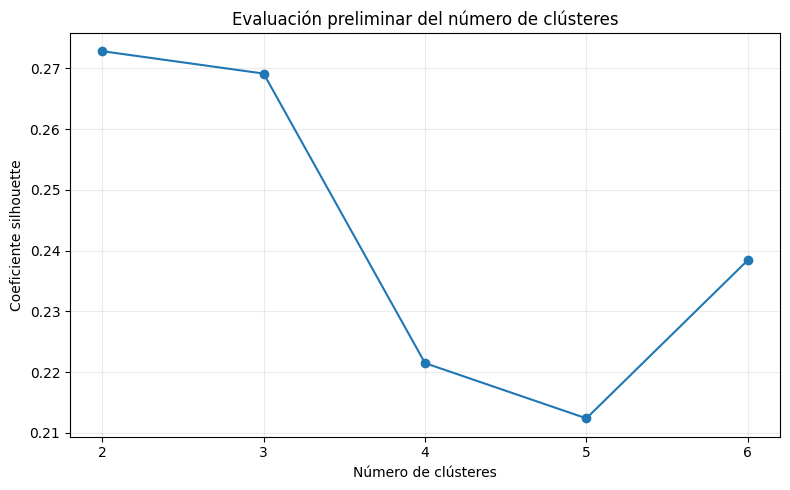

In [18]:

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    tabla_metricas_jerarquico["K"],
    tabla_metricas_jerarquico["SILHOUETTE"],
    marker="o"
)

ax.set_xticks(
    tabla_metricas_jerarquico["K"]
)

ax.set_xlabel(
    "Número de clústeres"
)

ax.set_ylabel(
    "Coeficiente silhouette"
)

ax.set_title(
    "Evaluación preliminar del número de clústeres"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


RUTA_FIG_SILHOUETTE = (
    FIGURES_DIR
    / "fig_06_silhouette_clustering_jerarquico.png"
)

fig.savefig(
    RUTA_FIG_SILHOUETTE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [19]:
# Mostrar asignaciones para cada k

print(
    "\nAsignaciones jerárquicas preliminares:"
)

display(
    asignaciones_jerarquicas
)


RUTA_METRICAS_JERARQUICO = (
    FEATURES_DIR
    / "metricas_clustering_jerarquico_2020_2025.csv"
)

RUTA_ASIGNACIONES_JERARQUICO = (
    FEATURES_DIR
    / "asignaciones_clustering_jerarquico_2020_2025.csv"
)

RUTA_MATRIZ_ENLACE = (
    FEATURES_DIR
    / "matriz_enlace_ward_2020_2025.csv"
)


tabla_metricas_jerarquico.to_csv(
    RUTA_METRICAS_JERARQUICO,
    index=False,
    encoding="utf-8-sig"
)

asignaciones_jerarquicas.to_csv(
    RUTA_ASIGNACIONES_JERARQUICO,
    encoding="utf-8-sig"
)

pd.DataFrame(
    matriz_enlace_ward,
    columns=[
        "CLUSTER_1",
        "CLUSTER_2",
        "DISTANCIA",
        "TAMANO_NUEVO_CLUSTER"
    ]
).to_csv(
    RUTA_MATRIZ_ENLACE,
    index=False,
    encoding="utf-8-sig"
)




Asignaciones jerárquicas preliminares:


,CLUSTER_K2,CLUSTER_K3,CLUSTER_K4,CLUSTER_K5,CLUSTER_K6
ESTADO,,,,,
AGUASCALIENTES,2,2,2,1,3
BAJA CALIFORNIA,2,2,2,1,1
BAJA CALIFORNIA SUR,1,1,4,4,4
CAMPECHE,1,1,4,4,4
CHIAPAS,1,1,1,5,5
CHIHUAHUA,2,2,2,1,3
COAHUILA,1,1,1,2,2
COLIMA,1,1,4,4,4
DISTRITO FEDERAL,2,2,2,1,1


## 10. Comparación de las soluciones con dos y tres clústeres

Los criterios internos no proporcionan una respuesta única sobre el número de grupos.

La solución con dos clústeres presenta los mejores valores de silhouette y Calinski--Harabasz:

$$
\operatorname{Silhouette}(k=2)=0.2728.
$$

Sin embargo, la solución con tres clústeres conserva un valor silhouette muy similar,

$$
\operatorname{Silhouette}(k=3)=0.2691,
$$

y mejora el índice de Davies--Bouldin. Además, el dendrograma sugiere que Guerrero y Tabasco forman una rama diferenciada respecto a las demás entidades.

Por otro lado, aunque $k=6$ obtiene el menor índice de Davies--Bouldin, genera varios grupos con pocos estados y una partición considerablemente más fragmentada. Para esta primera etapa no se considerará como solución principal.

A continuación se compararán las particiones con $k=2$ y $k=3$ mediante:

- tamaño de los clústeres;
- entidades que integran cada grupo;
- medianas de las características epidemiológicas originales;
- medias de las características estandarizadas.

La numeración de los clústeres es arbitraria y no implica un orden epidemiológico. La selección de una partición para la presentación se realizará considerando conjuntamente separación, tamaño e interpretabilidad.

In [20]:
# Comparación de las soluciones k = 2 y k = 3



# Función para calcular la media circular de la semana pico


def media_circular_semana(semanas, periodo=52):
    """
    Calcula la semana promedio considerando que las semanas
    52 y 1 son temporalmente cercanas.
    """

    semanas = np.asarray(
        semanas,
        dtype=float
    )

    angulos = (
        2
        * np.pi
        * (semanas - 1)
        / periodo
    )

    seno_medio = np.mean(
        np.sin(angulos)
    )

    coseno_medio = np.mean(
        np.cos(angulos)
    )

    angulo_medio = np.arctan2(
        seno_medio,
        coseno_medio
    )

    if angulo_medio < 0:
        angulo_medio += 2 * np.pi

    semana_media = (
        1
        + periodo
        * angulo_medio
        / (2 * np.pi)
    )

    if semana_media > periodo:
        semana_media -= periodo

    return float(semana_media)


# Soluciones que se compararán

soluciones_comparadas = {
    2: asignaciones_jerarquicas[
        "CLUSTER_K2"
    ].copy(),

    3: asignaciones_jerarquicas[
        "CLUSTER_K3"
    ].copy()
}


# Tabla de integrantes por clúster

filas_integrantes = []

for k, etiquetas in soluciones_comparadas.items():

    for cluster in sorted(
        etiquetas.unique()
    ):

        estados_cluster_k = (
            etiquetas.loc[
                etiquetas == cluster
            ]
            .index
            .tolist()
        )

        filas_integrantes.append(
            {
                "K": k,
                "CLUSTER": cluster,
                "N_ESTADOS": len(
                    estados_cluster_k
                ),
                "ESTADOS": ", ".join(
                    estados_cluster_k
                )
            }
        )


tabla_integrantes_clusters = pd.DataFrame(
    filas_integrantes
)


print(
    "Integrantes de las soluciones "
    "con dos y tres clústeres:"
)

display(
    tabla_integrantes_clusters
)

Integrantes de las soluciones con dos y tres clústeres:


,K,CLUSTER,N_ESTADOS,ESTADOS
0,2,1,25,"BAJA CALIFORNIA SUR, CAMPECHE, CHIAPAS, COAHUI..."
1,2,2,7,"AGUASCALIENTES, BAJA CALIFORNIA, CHIHUAHUA, DI..."
2,3,1,23,"BAJA CALIFORNIA SUR, CAMPECHE, CHIAPAS, COAHUI..."
3,3,2,7,"AGUASCALIENTES, BAJA CALIFORNIA, CHIHUAHUA, DI..."
4,3,3,2,"GUERRERO, TABASCO"



Perfiles epidemiológicos de los clústeres en su escala original:


,K,CLUSTER,N_ESTADOS,INC_P90_MEDIANA,INC_CV_MEDIANA,PROP_CERO_MEDIANA,ACF1_MEDIANA,NUM_EPISODIOS_MEDIANA,CAMBIO_RECIENTE_MEDIANA,CONCENTRACION_TOP13_MEDIANA,FUERZA_ESTACIONAL_MEDIANA,SEMANA_PICO_CIRCULAR
0,2,1,25,2.1799,2.1690,0.2949,0.9630,22.0000,0.4891,0.6260,0.2508,39.0518
1,2,2,7,0.0594,3.9417,0.7949,0.8348,19.0000,0.0352,0.8438,0.1849,41.9254
2,3,1,23,1.9610,2.1967,0.3013,0.9640,22.0000,0.4669,0.6495,0.2600,38.4262
3,3,2,7,0.0594,3.9417,0.7949,0.8348,19.0000,0.0352,0.8438,0.1849,41.9254
4,3,3,2,2.9722,1.8234,0.1202,0.9252,14.5000,0.7483,0.4602,0.1303,4.5000


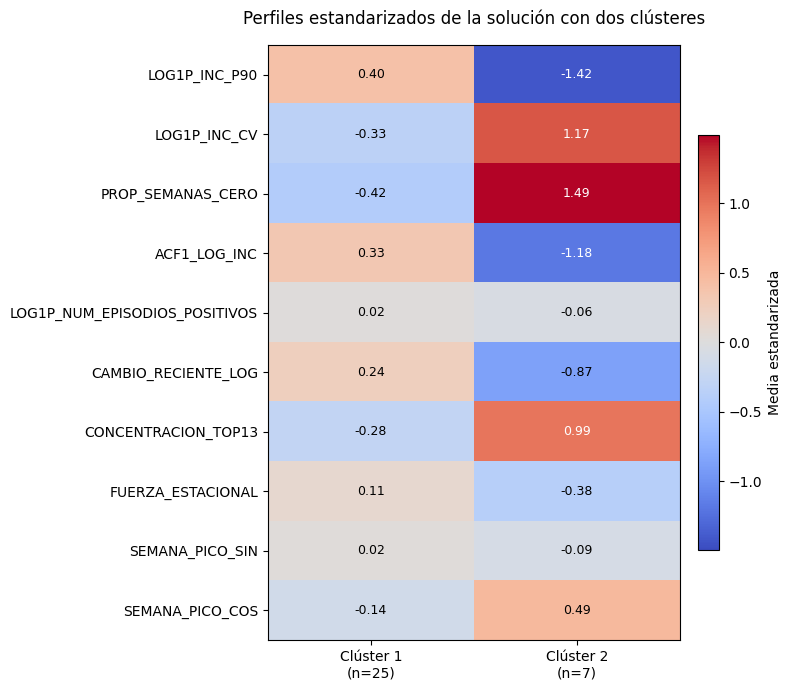

In [21]:
# Variables interpretables en su escala original

features_interpretables = pd.DataFrame(
    index=features_finales_originales.index
)

features_interpretables.index.name = "ESTADO"

features_interpretables[
    "INC_P90"
] = features_finales_originales[
    "INC_P90"
]

features_interpretables[
    "INC_CV"
] = features_finales_originales[
    "INC_CV"
]

features_interpretables[
    "PROP_SEMANAS_CERO"
] = features_finales_originales[
    "PROP_SEMANAS_CERO"
]

features_interpretables[
    "ACF1_LOG_INC"
] = features_finales_originales[
    "ACF1_LOG_INC"
]

features_interpretables[
    "NUM_EPISODIOS_POSITIVOS"
] = features_finales_originales[
    "NUM_EPISODIOS_POSITIVOS"
]

features_interpretables[
    "CAMBIO_RECIENTE_LOG"
] = features_finales_originales[
    "CAMBIO_RECIENTE_LOG"
]

features_interpretables[
    "CONCENTRACION_TOP13"
] = features_finales_originales[
    "CONCENTRACION_TOP13"
]

features_interpretables[
    "FUERZA_ESTACIONAL"
] = features_finales_originales[
    "FUERZA_ESTACIONAL"
]

features_interpretables[
    "SEMANA_PICO"
] = features_estacionalidad[
    "SEMANA_PICO"
]


# Resumen de los perfiles en escala original

resumen_perfiles = []

for k, etiquetas in soluciones_comparadas.items():

    for cluster in sorted(
        etiquetas.unique()
    ):

        estados_cluster_k = (
            etiquetas.loc[
                etiquetas == cluster
            ]
            .index
        )

        subconjunto = (
            features_interpretables
            .loc[estados_cluster_k]
        )

        resumen_perfiles.append(
            {
                "K": k,
                "CLUSTER": cluster,
                "N_ESTADOS": len(
                    estados_cluster_k
                ),

                "INC_P90_MEDIANA": (
                    subconjunto[
                        "INC_P90"
                    ].median()
                ),

                "INC_CV_MEDIANA": (
                    subconjunto[
                        "INC_CV"
                    ].median()
                ),

                "PROP_CERO_MEDIANA": (
                    subconjunto[
                        "PROP_SEMANAS_CERO"
                    ].median()
                ),

                "ACF1_MEDIANA": (
                    subconjunto[
                        "ACF1_LOG_INC"
                    ].median()
                ),

                "NUM_EPISODIOS_MEDIANA": (
                    subconjunto[
                        "NUM_EPISODIOS_POSITIVOS"
                    ].median()
                ),

                "CAMBIO_RECIENTE_MEDIANA": (
                    subconjunto[
                        "CAMBIO_RECIENTE_LOG"
                    ].median()
                ),

                "CONCENTRACION_TOP13_MEDIANA": (
                    subconjunto[
                        "CONCENTRACION_TOP13"
                    ].median()
                ),

                "FUERZA_ESTACIONAL_MEDIANA": (
                    subconjunto[
                        "FUERZA_ESTACIONAL"
                    ].median()
                ),

                "SEMANA_PICO_CIRCULAR": (
                    media_circular_semana(
                        subconjunto[
                            "SEMANA_PICO"
                        ]
                    )
                )
            }
        )


tabla_perfiles_clusters = pd.DataFrame(
    resumen_perfiles
)


print(
    "\nPerfiles epidemiológicos de los clústeres "
    "en su escala original:"
)

display(
    tabla_perfiles_clusters.round(4)
)


# Medias estandarizadas por clúster

perfiles_estandarizados = {}

for k, etiquetas in soluciones_comparadas.items():

    tabla_k = (
        features_estandarizadas
        .copy()
        .assign(
            CLUSTER=etiquetas
        )
        .groupby("CLUSTER")
        .mean()
        .T
    )

    perfiles_estandarizados[k] = tabla_k


# Mapa de calor para k = 2

perfil_k2 = perfiles_estandarizados[2]

limite_k2 = np.abs(
    perfil_k2.to_numpy()
).max()


fig, ax = plt.subplots(
    figsize=(8, 7)
)

imagen = ax.imshow(
    perfil_k2,
    vmin=-limite_k2,
    vmax=limite_k2,
    cmap="coolwarm",
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        perfil_k2.shape[1]
    )
)

ax.set_yticks(
    np.arange(
        perfil_k2.shape[0]
    )
)

tamanos_k2 = (
    soluciones_comparadas[2]
    .value_counts()
    .sort_index()
)

ax.set_xticklabels(
    [
        f"Clúster {cluster}\n"
        f"(n={tamanos_k2[cluster]})"
        for cluster in perfil_k2.columns
    ]
)

ax.set_yticklabels(
    perfil_k2.index
)

for i in range(
    perfil_k2.shape[0]
):

    for j in range(
        perfil_k2.shape[1]
    ):

        valor = perfil_k2.iloc[i, j]

        color_texto = (
            "white"
            if abs(valor)
            >= 0.60 * limite_k2
            else "black"
        )

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=color_texto
        )

ax.set_title(
    "Perfiles estandarizados de la solución con dos clústeres",
    pad=15
)

barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

barra.set_label(
    "Media estandarizada"
)

fig.tight_layout()


RUTA_FIG_PERFILES_K2 = (
    FIGURES_DIR
    / "fig_07_perfiles_estandarizados_k2.png"
)

fig.savefig(
    RUTA_FIG_PERFILES_K2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

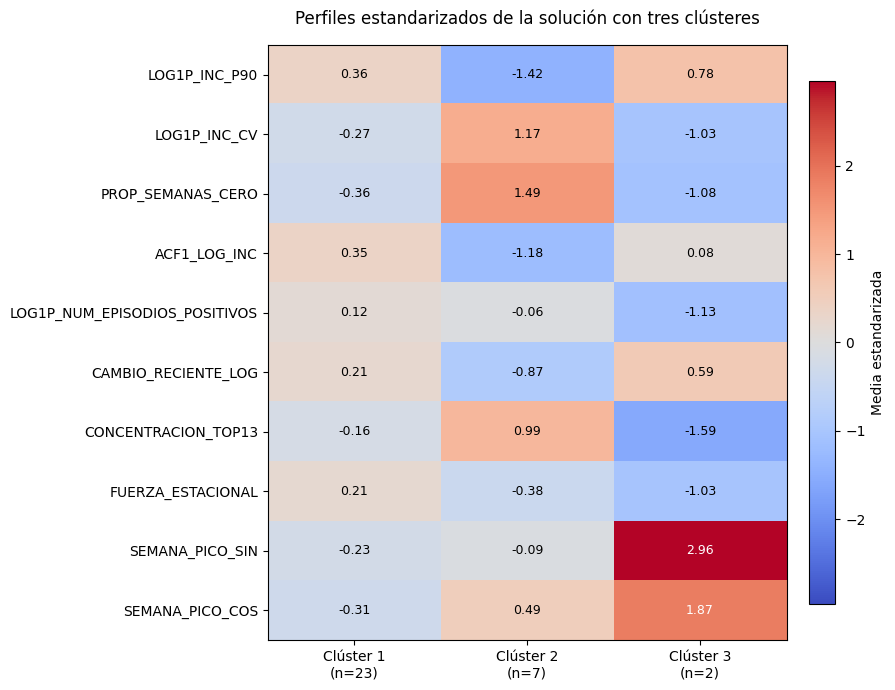

In [22]:
# Mapa de calor para k = 3

perfil_k3 = perfiles_estandarizados[3]

limite_k3 = np.abs(
    perfil_k3.to_numpy()
).max()


fig, ax = plt.subplots(
    figsize=(9, 7)
)

imagen = ax.imshow(
    perfil_k3,
    vmin=-limite_k3,
    vmax=limite_k3,
    cmap="coolwarm",
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        perfil_k3.shape[1]
    )
)

ax.set_yticks(
    np.arange(
        perfil_k3.shape[0]
    )
)

tamanos_k3 = (
    soluciones_comparadas[3]
    .value_counts()
    .sort_index()
)

ax.set_xticklabels(
    [
        f"Clúster {cluster}\n"
        f"(n={tamanos_k3[cluster]})"
        for cluster in perfil_k3.columns
    ]
)

ax.set_yticklabels(
    perfil_k3.index
)

for i in range(
    perfil_k3.shape[0]
):

    for j in range(
        perfil_k3.shape[1]
    ):

        valor = perfil_k3.iloc[i, j]

        color_texto = (
            "white"
            if abs(valor)
            >= 0.60 * limite_k3
            else "black"
        )

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=color_texto
        )

ax.set_title(
    "Perfiles estandarizados de la solución con tres clústeres",
    pad=15
)

barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

barra.set_label(
    "Media estandarizada"
)

fig.tight_layout()


RUTA_FIG_PERFILES_K3 = (
    FIGURES_DIR
    / "fig_08_perfiles_estandarizados_k3.png"
)

fig.savefig(
    RUTA_FIG_PERFILES_K3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Guardar resultados

RUTA_INTEGRANTES_COMPARACION = (
    FEATURES_DIR
    / "comparacion_integrantes_clusters_k2_k3.csv"
)

RUTA_PERFILES_COMPARACION = (
    FEATURES_DIR
    / "comparacion_perfiles_clusters_k2_k3.csv"
)

RUTA_PERFILES_EST_K2 = (
    FEATURES_DIR
    / "perfiles_estandarizados_k2.csv"
)

RUTA_PERFILES_EST_K3 = (
    FEATURES_DIR
    / "perfiles_estandarizados_k3.csv"
)


tabla_integrantes_clusters.to_csv(
    RUTA_INTEGRANTES_COMPARACION,
    index=False,
    encoding="utf-8-sig"
)

tabla_perfiles_clusters.to_csv(
    RUTA_PERFILES_COMPARACION,
    index=False,
    encoding="utf-8-sig"
)

perfil_k2.to_csv(
    RUTA_PERFILES_EST_K2,
    encoding="utf-8-sig"
)

perfil_k3.to_csv(
    RUTA_PERFILES_EST_K3,
    encoding="utf-8-sig"
)

La solución con $k=3$ es defendible como resultado exploratorio del primer trimestre: conserva prácticamente el mismo silhouette que $k=2$, distingue al grupo de baja incidencia y separa a Guerrero y Tabasco por su pico temprano. Debe mantenerse la advertencia de que el tercer clúster contiene sólo dos estados y requiere validación posterior.

## 11. Visualización e interpretación de la solución exploratoria con tres clústeres

Para cerrar esta primera etapa se utilizará provisionalmente la solución jerárquica con $k=3$.

Esta elección no representa todavía la clasificación definitiva de las entidades federativas. Se adopta con fines exploratorios porque:

- su coeficiente silhouette es muy cercano al obtenido con \(k=2\);
- presenta un índice de Davies--Bouldin menor que la solución con dos grupos;
- conserva un clúster claramente asociado con baja incidencia e intermitencia;
- distingue a Guerrero y Tabasco, cuyos perfiles presentan un pico estacional mucho más temprano que el resto de las entidades.

La solución está formada por:

- un grupo mayoritario de 23 estados;
- un grupo de 7 estados con incidencia baja e intermitente;
- un grupo de 2 estados con actividad relativamente persistente y pico temprano.

Debido al reducido tamaño del tercer clúster, su existencia deberá evaluarse posteriormente mediante análisis de estabilidad, comparación con otros algoritmos y ventanas temporales móviles.

En esta sección se examinará:

1. el coeficiente silhouette de cada entidad;
2. la ubicación de los clústeres en el plano PCA;
3. el perfil estacional mediano de incidencia de cada grupo;
4. la variabilidad interna de los perfiles mediante el rango intercuartílico.

El perfil estacional de cada clúster se resumirá mediante la mediana de los perfiles estatales. Las bandas corresponderán a los percentiles 25 y 75.

In [23]:
# Diagnóstico y visualización de la solución exploratoria k = 3


# Etiquetas de la solución seleccionada provisionalmente

cluster_k3 = (
    asignaciones_jerarquicas["CLUSTER_K3"]
    .copy()
    .astype(int)
)

cluster_k3.name = "CLUSTER"


# Coeficiente silhouette por estado
silhouette_individual = silhouette_samples(
    X_cluster,
    cluster_k3.to_numpy()
)

tabla_diagnostico_k3 = pd.DataFrame(
    {
        "ESTADO": features_estandarizadas.index,
        "CLUSTER": cluster_k3.to_numpy(),
        "SILHOUETTE_INDIVIDUAL": silhouette_individual,
        "PC1": scores_pca.loc[
            features_estandarizadas.index,
            "PC1"
        ].to_numpy(),
        "PC2": scores_pca.loc[
            features_estandarizadas.index,
            "PC2"
        ].to_numpy(),
        "INC_P90": features_finales_originales.loc[
            features_estandarizadas.index,
            "INC_P90"
        ].to_numpy(),
        "PROP_SEMANAS_CERO": (
            features_finales_originales.loc[
                features_estandarizadas.index,
                "PROP_SEMANAS_CERO"
            ].to_numpy()
        ),
        "SEMANA_PICO": features_estacionalidad.loc[
            features_estandarizadas.index,
            "SEMANA_PICO"
        ].to_numpy()
    }
)

tabla_diagnostico_k3["ABREVIATURA"] = (
    tabla_diagnostico_k3["ESTADO"]
    .map(abreviaturas_estados)
)


# Resumen del silhouette por clúster

resumen_silhouette_k3 = (
    tabla_diagnostico_k3
    .groupby("CLUSTER")
    .agg(
        N_ESTADOS=("ESTADO", "size"),
        SILHOUETTE_MEDIO=(
            "SILHOUETTE_INDIVIDUAL",
            "mean"
        ),
        SILHOUETTE_MEDIANA=(
            "SILHOUETTE_INDIVIDUAL",
            "median"
        ),
        SILHOUETTE_MIN=(
            "SILHOUETTE_INDIVIDUAL",
            "min"
        ),
        SILHOUETTE_MAX=(
            "SILHOUETTE_INDIVIDUAL",
            "max"
        )
    )
    .reset_index()
)


print(
    "Resumen del coeficiente silhouette "
    "por clúster:"
)

display(
    resumen_silhouette_k3.round(4)
)


print(
    "\nDiagnóstico individual de los estados:"
)

display(
    tabla_diagnostico_k3
    .sort_values(
        [
            "CLUSTER",
            "SILHOUETTE_INDIVIDUAL"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(4)
)

Resumen del coeficiente silhouette por clúster:


,CLUSTER,N_ESTADOS,SILHOUETTE_MEDIO,SILHOUETTE_MEDIANA,SILHOUETTE_MIN,SILHOUETTE_MAX
0,1,23,0.2659,0.2535,-0.0167,0.4739
1,2,7,0.2061,0.2404,-0.0562,0.3548
2,3,2,0.5265,0.5265,0.5055,0.5476



Diagnóstico individual de los estados:


,ESTADO,CLUSTER,SILHOUETTE_INDIVIDUAL,PC1,PC2,INC_P90,PROP_SEMANAS_CERO,SEMANA_PICO,ABREVIATURA
20,PUEBLA,1,0.4739,-1.0780,-0.5100,1.6649,0.1955,38,PUE
13,JALISCO,1,0.4311,-0.7727,-0.4769,2.4923,0.1571,41,JAL
23,SAN LUIS POTOSI,1,0.3949,-1.0101,0.0999,1.9610,0.3429,36,SLP
17,NAYARIT,1,0.3772,-1.5554,-0.8436,4.0476,0.3013,36,NAY
27,TAMAULIPAS,1,0.3547,-0.1995,-0.2110,1.4914,0.2949,39,TAMPS
12,HIDALGO,1,0.3390,0.1386,-0.5839,1.1092,0.4071,40,HGO
24,SINALOA,1,0.3227,-0.6034,-1.4420,3.0087,0.1282,41,SIN
4,CHIAPAS,1,0.3175,-2.0720,0.1578,1.7518,0.0833,35,CHIS
16,MORELOS,1,0.3169,-2.7470,-0.7120,6.6137,0.1122,34,MOR
15,MICHOACAN,1,0.3142,-1.9447,0.2469,2.1799,0.0833,38,MICH


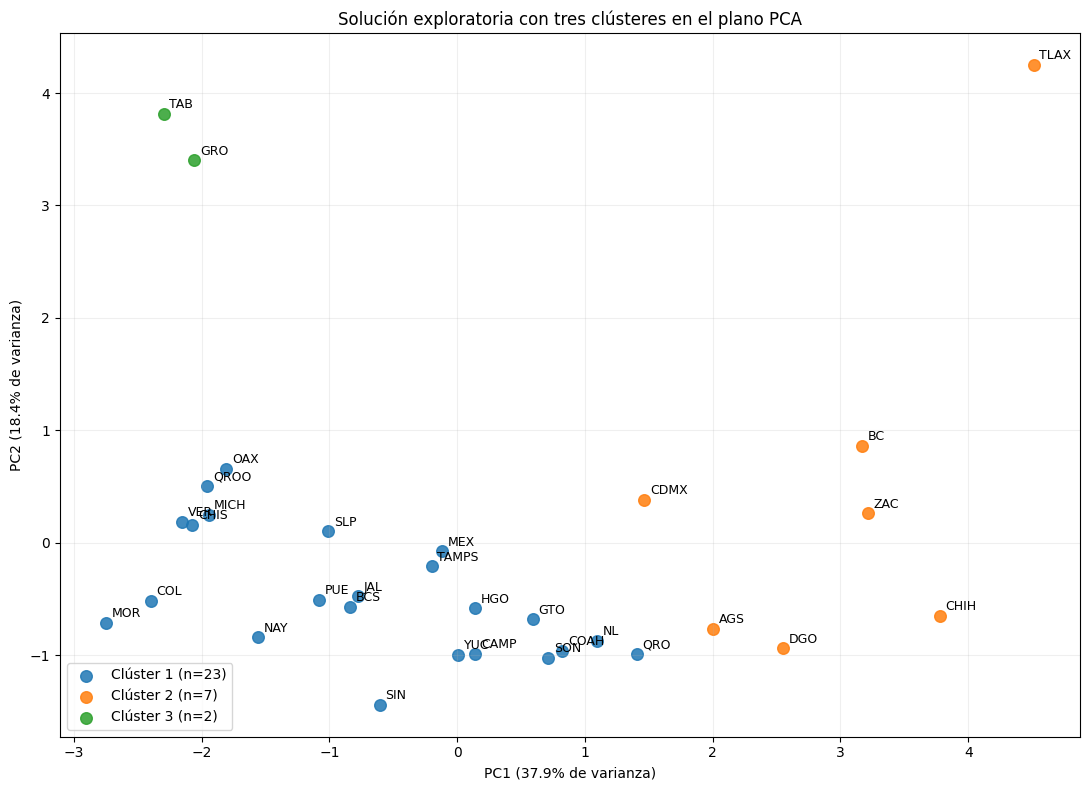

In [24]:
# Figura: PCA coloreado por clúster

fig, ax = plt.subplots(
    figsize=(11, 8)
)

clusters_ordenados = sorted(
    cluster_k3.unique()
)

for cluster in clusters_ordenados:

    estados_del_cluster = (
        cluster_k3.loc[
            cluster_k3 == cluster
        ]
        .index
    )

    ax.scatter(
        scores_pca.loc[
            estados_del_cluster,
            "PC1"
        ],
        scores_pca.loc[
            estados_del_cluster,
            "PC2"
        ],
        s=70,
        alpha=0.85,
        label=(
            f"Clúster {cluster} "
            f"(n={len(estados_del_cluster)})"
        )
    )

    for estado in estados_del_cluster:

        ax.annotate(
            abreviaturas_estados[estado],
            (
                scores_pca.loc[estado, "PC1"],
                scores_pca.loc[estado, "PC2"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=9
        )



ax.set_xlabel(
    f"PC1 ({var_pc1:.1f}% de varianza)"
)

ax.set_ylabel(
    f"PC2 ({var_pc2:.1f}% de varianza)"
)

ax.set_title(
    "Solución exploratoria con tres clústeres en el plano PCA"
)

ax.grid(
    alpha=0.20
)

ax.legend()

fig.tight_layout()


RUTA_FIG_PCA_K3 = (
    FIGURES_DIR
    / "fig_09_pca_clusters_k3.png"
)

fig.savefig(
    RUTA_FIG_PCA_K3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

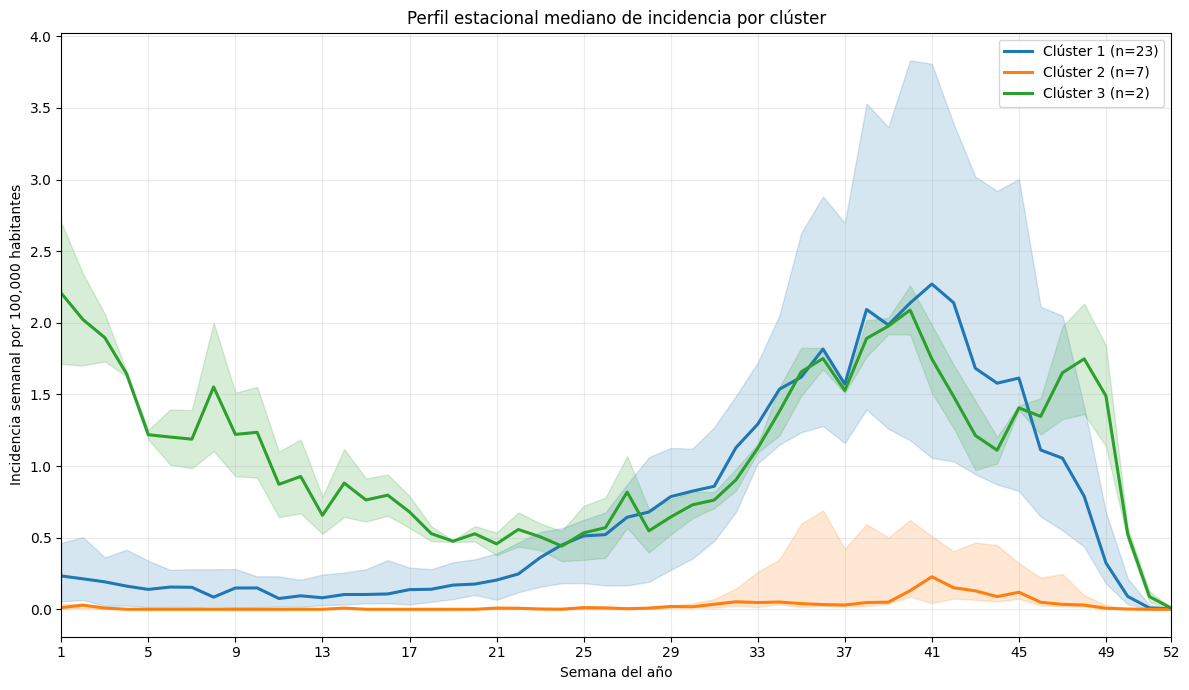

In [25]:
# Perfiles estacionales por clúster

perfiles_cluster_k3 = {}

for cluster in clusters_ordenados:

    estados_del_cluster = (
        cluster_k3.loc[
            cluster_k3 == cluster
        ]
        .index
    )

    subconjunto = (
        perfil_estacional[
            estados_del_cluster
        ]
    )

    perfiles_cluster_k3[cluster] = pd.DataFrame(
        {
            "MEDIANA": subconjunto.median(
                axis=1
            ),
            "Q25": subconjunto.quantile(
                0.25,
                axis=1
            ),
            "Q75": subconjunto.quantile(
                0.75,
                axis=1
            )
        }
    )



# Figura: perfiles estacionales medianos

fig, ax = plt.subplots(
    figsize=(12, 7)
)

for cluster in clusters_ordenados:

    perfil_cluster = (
        perfiles_cluster_k3[cluster]
    )

    semanas = (
        perfil_cluster.index.to_numpy()
    )

    mediana = (
        perfil_cluster["MEDIANA"]
        .to_numpy()
    )

    q25 = (
        perfil_cluster["Q25"]
        .to_numpy()
    )

    q75 = (
        perfil_cluster["Q75"]
        .to_numpy()
    )

    n_estados = int(
        (cluster_k3 == cluster).sum()
    )

    linea = ax.plot(
        semanas,
        mediana,
        linewidth=2.2,
        label=(
            f"Clúster {cluster} "
            f"(n={n_estados})"
        )
    )[0]

    ax.fill_between(
        semanas,
        q25,
        q75,
        alpha=0.18,
        color=linea.get_color()
    )


ax.set_xticks(
    [
        1,
        5,
        9,
        13,
        17,
        21,
        25,
        29,
        33,
        37,
        41,
        45,
        49,
        52
    ]
)

ax.set_xlim(
    1,
    52
)

ax.set_xlabel(
    "Semana del año"
)

ax.set_ylabel(
    "Incidencia semanal por 100,000 habitantes"
)

ax.set_title(
    "Perfil estacional mediano de incidencia por clúster"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


RUTA_FIG_PERFILES_ESTACIONALES_K3 = (
    FIGURES_DIR
    / "fig_10_perfiles_estacionales_clusters_k3.png"
)

fig.savefig(
    RUTA_FIG_PERFILES_ESTACIONALES_K3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
# Tabla de los perfiles estacionales

tabla_perfiles_estacionales_k3 = []

for cluster in clusters_ordenados:

    perfil_cluster = (
        perfiles_cluster_k3[cluster]
        .copy()
        .reset_index()
    )

    perfil_cluster["CLUSTER"] = cluster

    tabla_perfiles_estacionales_k3.append(
        perfil_cluster
    )


tabla_perfiles_estacionales_k3 = pd.concat(
    tabla_perfiles_estacionales_k3,
    ignore_index=True
)

tabla_perfiles_estacionales_k3 = (
    tabla_perfiles_estacionales_k3[
        [
            "CLUSTER",
            "SEMANA_ESTACIONAL",
            "MEDIANA",
            "Q25",
            "Q75"
        ]
    ]
)



# Guardar resultados


RUTA_DIAGNOSTICO_K3 = (
    FEATURES_DIR
    / "diagnostico_estados_cluster_k3.csv"
)

RUTA_RESUMEN_SILHOUETTE_K3 = (
    FEATURES_DIR
    / "resumen_silhouette_cluster_k3.csv"
)

RUTA_PERFILES_ESTACIONALES_K3 = (
    FEATURES_DIR
    / "perfiles_estacionales_clusters_k3.csv"
)


tabla_diagnostico_k3.to_csv(
    RUTA_DIAGNOSTICO_K3,
    index=False,
    encoding="utf-8-sig"
)

resumen_silhouette_k3.to_csv(
    RUTA_RESUMEN_SILHOUETTE_K3,
    index=False,
    encoding="utf-8-sig"
)

tabla_perfiles_estacionales_k3.to_csv(
    RUTA_PERFILES_ESTACIONALES_K3,
    index=False,
    encoding="utf-8-sig"
)

Los resultados confirman que la solución es útil como avance, pero todavía preliminar:

- El clúster 3, formado por Guerrero y Tabasco, es el más compacto: silhouette medio 0.5265.
- El clúster 1 contiene la mayor heterogeneidad, aunque sólo Querétaro presenta silhouette ligeramente negativo.
- En el clúster 2, Ciudad de México tiene silhouette negativo y Aguascalientes un valor cercano a cero; deben considerarse estados fronterizos.
- El perfil estacional distingue claramente al clúster 2 por su baja incidencia y al clúster 3 por su actividad temprana.




## 12. Distribución espacial de la solución exploratoria

La ubicación geográfica no se utilizó como variable para construir los clústeres. Por tanto, cualquier patrón espacial observado en el mapa emerge únicamente de las semejanzas entre las trayectorias epidemiológicas estatales.

La solución exploratoria con tres grupos puede resumirse de la siguiente manera:

- **Clúster 1:** grupo mayoritario con actividad relativamente persistente, incidencia media o alta y un pico concentrado principalmente durante la segunda mitad del año.
- **Clúster 2:** entidades con incidencia baja, elevada proporción de semanas sin casos y menor crecimiento reciente.
- **Clúster 3:** Guerrero y Tabasco, caracterizados por incidencia persistente y un pico estacional considerablemente más temprano.

Estas denominaciones son descriptivas y provisionales. Durante el siguiente trimestre será necesario evaluar:

- estabilidad de las asignaciones;
- sensibilidad a la selección de características;
- comparación con otros algoritmos;
- evolución de los clústeres mediante ventanas temporales móviles.

El mapa permitirá examinar si los perfiles epidemiológicos presentan alguna organización regional, aun cuando no se impuso contigüidad espacial durante el clustering.

In [27]:
# Mapa de la solución exploratoria con k = 3


# Función para homologar nombres estatales
def normalizar_nombre_estado(nombre):
    """
    Convierte un nombre estatal a mayúsculas, elimina acentos
    y homologa algunas denominaciones extensas.
    """

    nombre = str(nombre).strip().upper()

    nombre = "".join(
        caracter
        for caracter in unicodedata.normalize("NFD", nombre)
        if unicodedata.category(caracter) != "Mn"
    )

    equivalencias = {
        "CIUDAD DE MEXICO": "DISTRITO FEDERAL",
        "CDMX": "DISTRITO FEDERAL",
        "ESTADO DE MEXICO": "MEXICO",
        "MEXICO, ESTADO DE": "MEXICO",
        "VERACRUZ DE IGNACIO DE LA LLAVE": "VERACRUZ",
        "MICHOACAN DE OCAMPO": "MICHOACAN",
        "COAHUILA DE ZARAGOZA": "COAHUILA",
        "QUERETARO DE ARTEAGA": "QUERETARO",
        "QUERETARO DE ARTEAGA.": "QUERETARO"
    }

    return equivalencias.get(
        nombre,
        nombre
    )



ruta_geojson = "https://raw.githubusercontent.com/strotgen/mexico-leaflet/refs/heads/master/states.geojson"

estados_geo = gpd.read_file(ruta_geojson)

# Identificar la columna con los nombres de los estados

columnas_posibles_nombre = [
    "name",
    "NAME",
    "nombre",
    "NOMBRE",
    "NOMGEO",
    "estado",
    "ESTADO",
    "entidad",
    "ENTIDAD",
    "state_name",
    "STATE_NAME"
]

columna_nombre_geo = next(
    (
        columna
        for columna in columnas_posibles_nombre
        if columna in estados_geo.columns
    ),
    None
)

if columna_nombre_geo is None:

    raise KeyError(
        "No se identificó la columna que contiene "
        "los nombres estatales.\n"
        f"Columnas disponibles: {estados_geo.columns.tolist()}"
    )


print(
    "\nColumna geográfica utilizada para los nombres:"
)

display(columna_nombre_geo)


# Normalizar nombres geográficos

estados_geo = estados_geo.copy()

estados_geo["ESTADO_NORMALIZADO"] = (
    estados_geo[columna_nombre_geo]
    .map(normalizar_nombre_estado)
)


# Tabla de asignaciones
asignacion_mapa = (
    tabla_diagnostico_k3[
        [
            "ESTADO",
            "CLUSTER",
            "SILHOUETTE_INDIVIDUAL",
            "INC_P90",
            "PROP_SEMANAS_CERO",
            "SEMANA_PICO"
        ]
    ]
    .copy()
)

asignacion_mapa["ESTADO"] = (
    asignacion_mapa["ESTADO"]
    .map(normalizar_nombre_estado)
)


# Etiquetas descriptivas provisionales

nombres_clusters = {
    1: "Perfil mayoritario persistente",
    2: "Baja incidencia e intermitencia",
    3: "Actividad con pico temprano"
}

asignacion_mapa["PERFIL_CLUSTER"] = (
    asignacion_mapa["CLUSTER"]
    .map(nombres_clusters)
)


# Unir geometrías y asignaciones

mapa_clusters = estados_geo.merge(
    asignacion_mapa,
    left_on="ESTADO_NORMALIZADO",
    right_on="ESTADO",
    how="left",
    validate="one_to_one"
)


# Validación de la correspondencia

sin_cluster = (
    mapa_clusters.loc[
        mapa_clusters["CLUSTER"].isna(),
        [
            columna_nombre_geo,
            "ESTADO_NORMALIZADO"
        ]
    ]
)

if not sin_cluster.empty:

    print(
        "\nEntidades geográficas sin correspondencia:"
    )

    display(sin_cluster)

    raise ValueError(
        "No fue posible asignar un clúster "
        "a todas las geometrías estatales."
    )


assert mapa_clusters["CLUSTER"].notna().all()
assert mapa_clusters.shape[0] == 32

mapa_clusters["CLUSTER"] = (
    mapa_clusters["CLUSTER"]
    .astype(int)
)


print(
    "\nCorrespondencia geográfica completada:"
)

print(
    f"{mapa_clusters.shape[0]} entidades con clúster asignado."
)


# Resumen final de la solución exploratoria

tabla_resumen_clusters = (
    asignacion_mapa
    .groupby("CLUSTER")
    .agg(
        PERFIL=(
            "PERFIL_CLUSTER",
            "first"
        ),
        N_ESTADOS=(
            "ESTADO",
            "size"
        ),
        SILHOUETTE_MEDIO=(
            "SILHOUETTE_INDIVIDUAL",
            "mean"
        ),
        INC_P90_MEDIANA=(
            "INC_P90",
            "median"
        ),
        PROP_CERO_MEDIANA=(
            "PROP_SEMANAS_CERO",
            "median"
        ),
        SEMANA_PICO_MEDIANA=(
            "SEMANA_PICO",
            "median"
        ),
        ESTADOS=(
            "ESTADO",
            lambda serie: ", ".join(
                sorted(serie)
            )
        )
    )
    .reset_index()
)


print(
    "\nResumen de la solución exploratoria:"
)

display(
    tabla_resumen_clusters.round(4)
)


# Colores consistentes con la figura PCA

colores_clusters = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c"
]

mapa_colores = ListedColormap(
    colores_clusters
)



Columna geográfica utilizada para los nombres:


'state_name'


Correspondencia geográfica completada:
32 entidades con clúster asignado.

Resumen de la solución exploratoria:


,CLUSTER,PERFIL,N_ESTADOS,SILHOUETTE_MEDIO,INC_P90_MEDIANA,PROP_CERO_MEDIANA,SEMANA_PICO_MEDIANA,ESTADOS
0,1,Perfil mayoritario persistente,23,0.2659,1.9610,0.3013,38.0000,"BAJA CALIFORNIA SUR, CAMPECHE, CHIAPAS, COAHUI..."
1,2,Baja incidencia e intermitencia,7,0.2061,0.0594,0.7949,41.0000,"AGUASCALIENTES, BAJA CALIFORNIA, CHIHUAHUA, DI..."
2,3,Actividad con pico temprano,2,0.5265,2.9722,0.1202,4.5000,"GUERRERO, TABASCO"


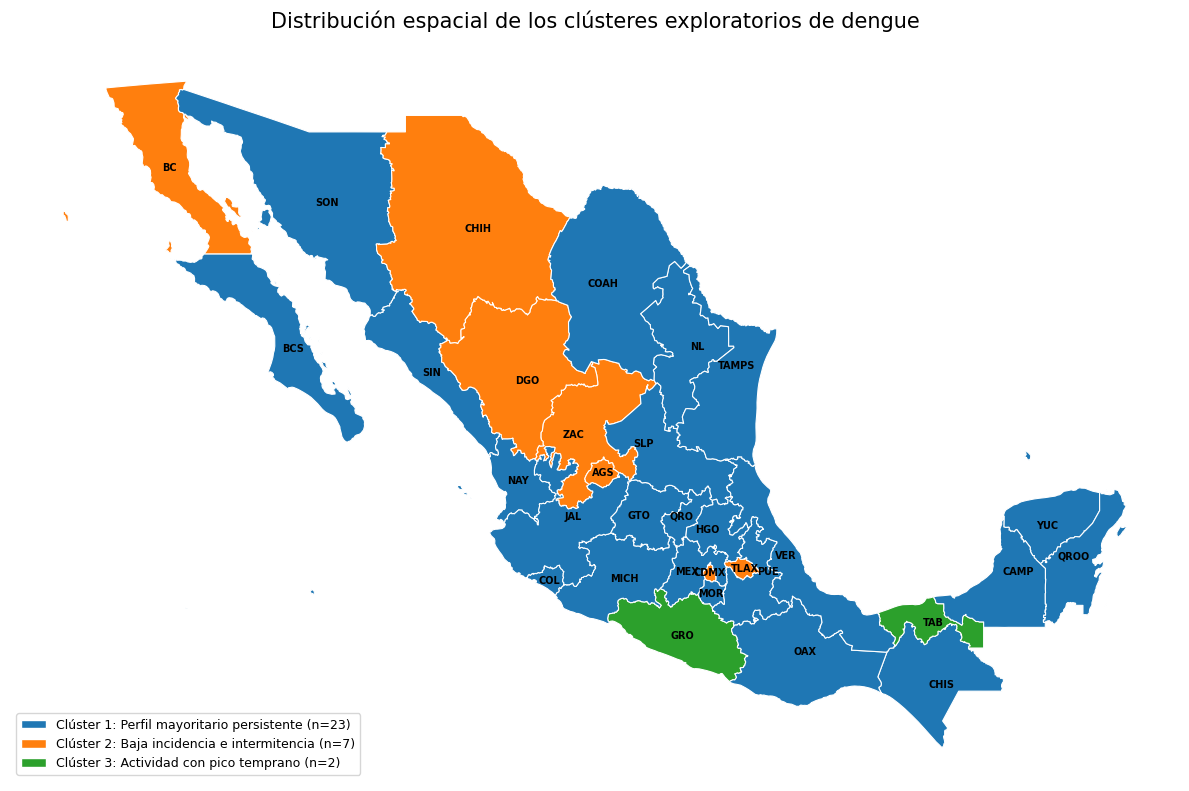

In [28]:
fig, ax = plt.subplots(
    figsize=(12, 8)
)

mapa_clusters.plot(
    column="CLUSTER",
    categorical=True,
    cmap=mapa_colores,
    linewidth=0.8,
    edgecolor="white",
    ax=ax
)



puntos_etiquetas = (
    mapa_clusters
    .geometry
    .representative_point()
)

for posicion, fila in mapa_clusters.iterrows():

    estado = fila["ESTADO"]

    abreviatura = (
        abreviaturas_estados
        .get(
            estado,
            estado[:3]
        )
    )

    punto = puntos_etiquetas.loc[
        posicion
    ]

    ax.text(
        punto.x,
        punto.y,
        abreviatura,
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold"
    )



elementos_leyenda = []

for cluster in [1, 2, 3]:

    n_estados = int(
        (
            asignacion_mapa["CLUSTER"]
            == cluster
        ).sum()
    )

    elementos_leyenda.append(
        Patch(
            facecolor=colores_clusters[
                cluster - 1
            ],
            edgecolor="white",
            label=(
                f"Clúster {cluster}: "
                f"{nombres_clusters[cluster]} "
                f"(n={n_estados})"
            )
        )
    )


ax.legend(
    handles=elementos_leyenda,
    loc="lower left",
    frameon=True,
    fontsize=9
)

ax.set_title(
    "Distribución espacial de los clústeres exploratorios de dengue",
    pad=15,
    fontsize=15
)

ax.set_axis_off()

fig.tight_layout()


RUTA_FIG_MAPA_CLUSTERS = (
    FIGURES_DIR
    / "fig_11_mapa_clusters_exploratorios_k3.png"
)

fig.savefig(
    RUTA_FIG_MAPA_CLUSTERS,
    dpi=300,
    bbox_inches="tight"
)

plt.show()




RUTA_ASIGNACION_FINAL_K3 = (
    FEATURES_DIR
    / "asignacion_exploratoria_clusters_k3.csv"
)

RUTA_RESUMEN_FINAL_K3 = (
    FEATURES_DIR
    / "resumen_exploratorio_clusters_k3.csv"
)

RUTA_GEOJSON_CLUSTERS = (
    FEATURES_DIR
    / "mapa_clusters_exploratorios_k3.geojson"
)


asignacion_mapa.to_csv(
    RUTA_ASIGNACION_FINAL_K3,
    index=False,
    encoding="utf-8-sig"
)

tabla_resumen_clusters.to_csv(
    RUTA_RESUMEN_FINAL_K3,
    index=False,
    encoding="utf-8-sig"
)

mapa_clusters.to_file(
    RUTA_GEOJSON_CLUSTERS,
    driver="GeoJSON"
)


## 13. Conclusiones del primer trimestre y trabajo futuro

Durante esta primera etapa se construyó una representación homogénea e interpretable de las trayectorias estatales de dengue en México.

### Avances alcanzados

Se integraron y validaron matrices semanales de:

- casos confirmados de dengue;
- incidencia por cada 100,000 habitantes;
- temperatura media;
- humedad relativa;
- precipitación.

Las matrices contienen información para las 32 entidades federativas y presentan una estructura temporal completamente alineada.

Para el análisis exploratorio se seleccionaron 312 semanas completas comprendidas entre el 12 de enero de 2020 y el 28 de diciembre de 2025. Este intervalo conserva $240\,688$ casos, equivalentes al $99.05\%$ de los registros disponibles en la base semanal.

A partir de las series estatales se construyeron características relacionadas con:

- magnitud de la incidencia;
- variabilidad;
- frecuencia de semanas sin casos;
- persistencia;
- fragmentación de los periodos con actividad;
- cambio entre 2020--2022 y 2023--2025;
- concentración y fuerza estacional;
- momento del pico epidemiológico.

Después del diagnóstico de redundancia se seleccionaron diez características. Ningún par presentó una correlación absoluta superior a $0.85$.


### Representación mediante componentes principales

El análisis de componentes principales mostró que:

$$
PC1 = 37.9\%,
\qquad
PC2 = 18.4\%,
$$

por lo que los dos primeros componentes explican conjuntamente $56.3\%$ de la variabilidad total.
Los primeros cuatro componentes acumulan aproximadamente $80.7\%$ de la variación.

El primer componente distingue principalmente entre entidades con actividad persistente e incidencia elevada y entidades con mayor intermitencia y concentración temporal. El segundo componente está fuertemente relacionado con el momento estacional del pico.

### Clustering exploratorio

Se aplicó clustering jerárquico mediante el método de Ward y se evaluaron soluciones con entre dos y seis clústeres.

La solución con dos grupos obtuvo los mejores valores de silhouette y Calinski--Harabasz. Sin embargo, la solución con tres clústeres presentó un valor silhouette muy similar y permitió distinguir un perfil epidemiológico particular formado por Guerrero y Tabasco.

De manera provisional se consideró la solución con tres clústeres:

1. **Perfil mayoritario persistente**, formado por 23 entidades. Presenta actividad relativamente continua, incidencia moderada o alta y un pico estacional alrededor de la semana 38.

2. **Baja incidencia e intermitencia**, formado por 7 entidades. Se caracteriza por una elevada proporción de semanas sin casos, baja incidencia y menor crecimiento reciente.

3. **Actividad con pico temprano**, formado por Guerrero y Tabasco. Presenta incidencia persistente y un máximo estacional cercano al inicio del año.

Los valores silhouette medios fueron:

$$
S_1=0.2659,
\qquad
S_2=0.2061,
\qquad
S_3=0.5265.
$$

Querétaro y Ciudad de México presentaron valores silhouette ligeramente negativos, mientras que Aguascalientes se encuentra cerca de la frontera de su grupo. Estas entidades deberán analizarse con mayor detalle durante la evaluación de estabilidad.

### Interpretación espacial

La ubicación geográfica no se utilizó para construir los clústeres. Por tanto, los patrones observados en el mapa emergen de las semejanzas entre las trayectorias epidemiológicas.

El grupo de baja incidencia e intermitencia presenta una concentración parcial en entidades del norte y centro del país. Guerrero y Tabasco conforman un grupo separado debido principalmente al momento temprano de su pico estacional.

### Alcance de los resultados

La partición obtenida debe considerarse exploratoria. En esta etapa todavía no se ha evaluado:

- estabilidad frente a remuestreo;
- sensibilidad a la selección de características;
- concordancia con otros algoritmos;
- evolución temporal de las membresías;
- incorporación de covariables climáticas al clustering;
- utilidad predictiva de los grupos.

Por tanto, estos resultados no representan todavía una clasificación epidemiológica definitiva.

## Trabajo para el segundo trimestre

La siguiente etapa se concentrará en desarrollar el componente dinámico del proyecto. Se propone:

1. comparar clustering jerárquico, k-means y modelos de mezcla gaussiana;
2. evaluar el número de clústeres mediante criterios internos y estabilidad;
3. analizar la sensibilidad de las particiones a la selección de características;
4. construir características mediante ventanas temporales móviles;
5. estimar los clústeres en distintos periodos;
6. estudiar los cambios de membresía de cada entidad;
7. incorporar de manera controlada características climáticas;
8. seleccionar una partición estable e interpretable para la fase de pronóstico.

En el tercer trimestre se utilizarán los clústeres obtenidos para comparar modelos globales y modelos especializados por grupo mediante backtesting temporal y pronóstico probabilístico.